<hr style="border: 2px solid #8E7B6B; margin-top: 10px;">
<h1 style="font-family:verdana; font-size:24px">
<br>
<center>Pengujian dan Analisis Feedforward Neural Network</center></h1>
<h2 style="font-family:verdana; font-size:16px"><center>Tugas Besar 1 IF3270 Pembelajaran Mesin 2025/2026 | Dataset: global_student_placement_and_salary</center></h2>

<br>

<hr style="border: 2px solid #8E7B6B; margin-top: 10px;">

## **Tim AlphaAziz**

- Leonard Arif Sutiono / 1823120
- Harfhan Ikhtiar Ahmad Ridzky / 18223123
- Izhar Alif Akbar / 18223129

<br>

<hr style="border: 2px solid #8E7B6B; margin-top: 10px;">

## Daftar Isi

1. [**Pendahuluan**](#1)
2. [**Inisialisasi**](#2)
3. [**Pemuatan Data dan Preprocessing**](#3)
4. [**Helper Eksperimen**](#4)
5. [**Analisis Width dan Depth**](#5)
6. [**Analisis Fungsi Aktivasi Hidden Layer**](#6)
7. [**Analisis Learning Rate**](#7)
8. [**Analisis Regularisasi**](#8)
9. [**Analisis Optimizer (Adam vs SGD)**](#9)
10. [**Analisis Normalisasi RMSNorm**](#10)
11. [**Perbandingan dengan sklearn MLP**](#11)
12. [**Ringkasan Akhir**](#12)

<hr style="border: 2px solid #8E7B6B; margin-top: 10px;">

# Pendahuluan <a name="1"></a>

<hr style="border: 2px solid #8E7B6B; margin-top: 10px;">

Notebook ini digunakan untuk menguji implementasi Feedforward Neural Network (FFNN) dari folder `src/model` pada dataset `global_student_placement_and_salary`. Seluruh pengujian mengikuti ketentuan spesifikasi tugas besar: analisis pengaruh width, depth, fungsi aktivasi hidden layer, learning rate, regularisasi, serta perbandingan dengan `sklearn MLP`.

Agar notebook tetap rapi dan mudah dijalankan ulang, alur kerja dibagi menjadi empat tahap utama: persiapan data, helper eksperimen, eksperimen inti, dan ringkasan akhir. Untuk menjaga visual tetap konsisten, bagian judul, pembatas section, tabel ringkas, dan gaya plot mengikuti pola penyajian pada notebook referensi.

<hr style="border: 2px solid #8E7B6B; margin-top: 10px;">

# Inisialisasi <a name="2"></a>

<hr style="border: 2px solid #8E7B6B; margin-top: 10px;">

## Instalasi dan Impor Pustaka

Sel ini menyiapkan dependensi utama yang dipakai notebook. Jika environment Anda sudah memiliki seluruh pustaka tersebut, sel instalasi dapat dilewati.

In [2]:
%pip install numpy pandas matplotlib seaborn scikit-learn tqdm

Note: you may need to restart the kernel to use updated packages.


In [3]:
import sys
import random
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from IPython.display import Markdown, display
from sklearn.compose import ColumnTransformer
from sklearn.exceptions import ConvergenceWarning
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import OneHotEncoder, StandardScaler

warnings.filterwarnings('ignore', category=ConvergenceWarning)

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / 'src').exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

SRC_DIR = PROJECT_ROOT / 'src'
DATA_PATH = SRC_DIR / 'data' / 'datasetml_2026.csv'

if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

from model.model import FFNN, Layer

SEED = 42
EPOCHS = 30
BATCH_SIZE = 32
BASE_LEARNING_RATE = 0.01
BASE_WIDTH = [32, 16]
BASE_ACTIVATIONS = ['relu', 'relu']

sns.set_theme(style='whitegrid')
plt.rcParams.update({
    'figure.figsize': (10, 5),
    'axes.titlesize': 13,
    'axes.labelsize': 11,
    'legend.fontsize': 10,
    'grid.color': '#E7E4DF'
})

BACKGROUND = 'white'
COLORS = ['#8E7B6B', '#C97B63', '#4C6A92', '#6F9E6E', '#A663CC']

def set_seed(seed=SEED):
    random.seed(seed)
    np.random.seed(seed)


def style_fig(fig, axes=None):
    fig.patch.set_facecolor(BACKGROUND)
    fig.patch.set_edgecolor('black')
    fig.patch.set_linewidth(1.5)
    if axes is not None:
        for ax in np.ravel(axes):
            if hasattr(ax, 'set_facecolor'):
                ax.set_facecolor(BACKGROUND)
    fig.tight_layout()


set_seed()
print(f'Project root  : {PROJECT_ROOT}')
print(f'Data path     : {DATA_PATH}')
print(f'Seed eksperimen: {SEED}')

Project root  : c:\Coding\machine learning\tubes1\TubesML
Data path     : c:\Coding\machine learning\tubes1\TubesML\src\data\datasetml_2026.csv
Seed eksperimen: 42


c:\python312\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


<hr style="border: 2px solid #8E7B6B; margin-top: 10px;">

# Pemuatan Data dan Preprocessing <a name="3"></a>

<hr style="border: 2px solid #8E7B6B; margin-top: 10px;">

Dataset berisi fitur numerik dan kategorikal dengan target biner `placement_status`. Pada notebook ini, target diubah menjadi label `1 = Placed` dan `0 = Not Placed`, lalu data dibagi menjadi train, validation, dan test agar seluruh eksperimen dibandingkan pada split yang sama.

In [4]:
df = pd.read_csv(DATA_PATH)

target_mapping = {'Placed': 1, 'Not Placed': 0}
df['placement_status_label'] = df['placement_status'].map(target_mapping)

numeric_features = [
    'cgpa',
    'backlogs',
    'internship_count',
    'aptitude_score',
    'communication_score',
    'internship_quality_score'
]

categorical_features = [
    'college_tier',
    'country',
    'university_ranking_band',
    'specialization',
    'industry'
]

print(f'Jumlah baris   : {len(df):,}')
print(f'Jumlah kolom   : {df.shape[1]}')
print('Distribusi target:')
display(df['placement_status'].value_counts().rename_axis('kelas').to_frame('jumlah'))

print('Contoh data:')
display(df.head())

ringkasan_fitur = pd.DataFrame({
    'tipe_fitur': ['numerik', 'kategorikal', 'target'],
    'daftar_kolom': [
        ', '.join(numeric_features),
        ', '.join(categorical_features),
        'placement_status_label'
    ]
})

display(ringkasan_fitur)

Jumlah baris   : 10,000
Jumlah kolom   : 13
Distribusi target:


,jumlah
kelas,
Placed,6153
Not Placed,3847


Contoh data:


,cgpa,backlogs,college_tier,country,university_ranking_band,internship_count,aptitude_score,communication_score,specialization,industry,internship_quality_score,placement_status,placement_status_label
0,7.397371,1,Tier 2,Canada,100-300,2,53.574150,64.177062,Data Science,Consulting,5.481450,Placed,1
1,6.889389,0,Tier 3,UK,300+,1,60.687750,88.346052,Data Science,Consulting,4.625099,Placed,1
2,7.518151,0,Tier 1,UK,100-300,2,64.568750,69.493171,Cybersecurity,Healthcare,5.227939,Placed,1
3,8.218424,0,Tier 2,UK,100-300,3,73.461500,78.204854,AI/ML,Tech,5.150674,Placed,1
4,6.812677,1,Tier 2,USA,100-300,4,86.518121,44.680881,Data Science,Consulting,3.888824,Placed,1


,tipe_fitur,daftar_kolom
0,numerik,"cgpa, backlogs, internship_count, aptitude_sco..."
1,kategorikal,"college_tier, country, university_ranking_band..."
2,target,placement_status_label


In [5]:
X = df[numeric_features + categorical_features]
y = df['placement_status_label'].to_numpy().reshape(-1, 1)

X_train_df, X_test_df, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=SEED,
    stratify=y
)

X_train_df, X_val_df, y_train, y_val = train_test_split(
    X_train_df,
    y_train,
    test_size=0.25,
    random_state=SEED,
    stratify=y_train
)

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features),
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), categorical_features)
    ]
)

X_train = preprocessor.fit_transform(X_train_df).astype(np.float64)
X_val = preprocessor.transform(X_val_df).astype(np.float64)
X_test = preprocessor.transform(X_test_df).astype(np.float64)

feature_names = preprocessor.get_feature_names_out()
input_dim = X_train.shape[1]

print(f'Ukuran train      : {X_train.shape}')
print(f'Ukuran validation : {X_val.shape}')
print(f'Ukuran test       : {X_test.shape}')
print(f'Jumlah fitur akhir: {input_dim}')

Ukuran train      : (6000, 28)
Ukuran validation : (2000, 28)
Ukuran test       : (2000, 28)
Jumlah fitur akhir: 28


<hr style="border: 2px solid #8E7B6B; margin-top: 10px;">

# Helper Eksperimen <a name="4"></a>

<hr style="border: 2px solid #8E7B6B; margin-top: 10px;">

Bagian ini memusatkan fungsi pembangun model, training, evaluasi, serta visualisasi. Dengan helper yang konsisten, setiap eksperimen dapat ditulis singkat dan hasilnya mudah dibandingkan.

In [6]:
def build_ffnn(hidden_layers, hidden_activations, learning_rate=BASE_LEARNING_RATE,
               regularization_type=None, lam=0.0, init_method='uniform', init_kwargs=None, 
               optimizer='adam', use_rmsnorm=False):
    model = FFNN(loss_name='bce', regularization_type=regularization_type, lam=lam, optimizer=optimizer)
    previous_dim = input_dim

    for neurons, activation in zip(hidden_layers, hidden_activations):
        model.add_layer(Layer(previous_dim, neurons, activation, use_rmsnorm=use_rmsnorm))
        previous_dim = neurons

    model.add_layer(Layer(previous_dim, 1, 'sigmoid', use_rmsnorm=False))

    if init_kwargs is None:
        init_kwargs = {'lower_bound': -0.05, 'upper_bound': 0.05}

    model.initialize_weights(method=init_method, input_dim=input_dim, **init_kwargs)
    return model


def predict_proba_ffnn(model, X_data):
    return np.clip(model.forward(X_data).reshape(-1), 1e-7, 1 - 1e-7)


def predict_label_ffnn(model, X_data, threshold=0.5):
    return (predict_proba_ffnn(model, X_data) >= threshold).astype(int)


def compute_metrics(y_true, y_pred):
    y_true = np.asarray(y_true).reshape(-1)
    y_pred = np.asarray(y_pred).reshape(-1)
    return {
        'accuracy': accuracy_score(y_true, y_pred),
        'precision': precision_score(y_true, y_pred, zero_division=0),
        'recall': recall_score(y_true, y_pred, zero_division=0),
        'f1': f1_score(y_true, y_pred, zero_division=0)
    }


def to_metric_frame(results):
    rows = []
    for result in results:
        rows.append({
            'Eksperimen': result['name'],
            'Accuracy': result['metrics']['accuracy'],
            'Precision': result['metrics']['precision'],
            'Recall': result['metrics']['recall'],
            'F1': result['metrics']['f1']
        })
    return pd.DataFrame(rows).sort_values('F1', ascending=False).reset_index(drop=True)


def get_layer_labels(model):
    labels = []
    for idx in range(len(model.layers)):
        if idx == len(model.layers) - 1:
            labels.append('Output')
        else:
            labels.append(f'Hidden {idx + 1}')
    return labels


def plot_loss_curves(results, title):
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    epochs_axis = np.arange(1, len(results[0]['history']['train_loss']) + 1)

    for idx, result in enumerate(results):
        color = COLORS[idx % len(COLORS)]
        axes[0].plot(epochs_axis, result['history']['train_loss'], linewidth=2, color=color, label=result['name'])
        axes[1].plot(epochs_axis, result['history']['val_loss'], linewidth=2, color=color, label=result['name'])

    axes[0].set_title('Training Loss per Epoch')
    axes[1].set_title('Validation Loss per Epoch')

    for ax in axes:
        ax.set_xlabel('Epoch')
        ax.set_ylabel('Loss')
        ax.legend()

    fig.suptitle(title, fontsize=14)
    style_fig(fig, axes)
    plt.show()


def plot_parameter_overview(model, experiment_name):
    layer_labels = get_layer_labels(model)

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    for idx, label in enumerate(layer_labels):
        params = np.concatenate([model.layers[idx].W.flatten(), model.layers[idx].b.flatten()])
        grads = np.concatenate([model.layers[idx].dW.flatten(), model.layers[idx].db.flatten()])
        axes[0].hist(params, bins=30, alpha=0.45, label=label)
        axes[1].hist(grads, bins=30, alpha=0.45, label=label)

    axes[0].set_title('Distribusi Bobot + Bias (Gabungan)')
    axes[1].set_title('Distribusi Gradien Bobot + Bias (Gabungan)')
    axes[0].set_xlabel('Nilai')
    axes[1].set_xlabel('Nilai')
    axes[0].set_ylabel('Frekuensi')
    axes[1].set_ylabel('Frekuensi')
    axes[0].legend()
    axes[1].legend()
    fig.suptitle(f'Ringkasan Distribusi Parameter | {experiment_name}', fontsize=14)
    style_fig(fig, axes)
    plt.show()

    fig, axes = plt.subplots(len(model.layers), 2, figsize=(12, 4 * len(model.layers)))
    if len(model.layers) == 1:
        axes = np.array([axes])

    for idx, label in enumerate(layer_labels):
        params = np.concatenate([model.layers[idx].W.flatten(), model.layers[idx].b.flatten()])
        grads = np.concatenate([model.layers[idx].dW.flatten(), model.layers[idx].db.flatten()])

        axes[idx, 0].hist(params, bins=30, color='#4C6A92', alpha=0.8)
        axes[idx, 1].hist(grads, bins=30, color='#C97B63', alpha=0.8)
        axes[idx, 0].set_title(f'{label} | Bobot + Bias')
        axes[idx, 1].set_title(f'{label} | Gradien Bobot + Bias')
        axes[idx, 0].set_xlabel('Nilai')
        axes[idx, 1].set_xlabel('Nilai')
        axes[idx, 0].set_ylabel('Frekuensi')
        axes[idx, 1].set_ylabel('Frekuensi')

    fig.suptitle(f'Distribusi per Layer | {experiment_name}', fontsize=14, y=1.02)
    style_fig(fig, axes)
    plt.show()


def run_ffnn_experiment(name, hidden_layers, hidden_activations, learning_rate=BASE_LEARNING_RATE,
                        epochs=EPOCHS, batch_size=BATCH_SIZE, regularization_type=None,
                        lam=0.0, init_method='uniform', init_kwargs=None, optimizer='sgd', 
                        use_rmsnorm=False, verbose=0):
    set_seed()
    model = build_ffnn(
        hidden_layers=hidden_layers,
        hidden_activations=hidden_activations,
        learning_rate=learning_rate,
        regularization_type=regularization_type,
        lam=lam,
        init_method=init_method,
        init_kwargs=init_kwargs,
        optimizer=optimizer,
        use_rmsnorm=use_rmsnorm
    )

    model.fit(
        X_train=X_train,
        y_train=y_train,
        X_val=X_val,
        y_val=y_val,
        epochs=epochs,
        batch_size=batch_size,
        learning_rate=learning_rate,
        verbose=verbose
    )

    test_predictions = predict_label_ffnn(model, X_test)
    metrics = compute_metrics(y_test, test_predictions)

    return {
        'name': name,
        'model': model,
        'history': model.history,
        'metrics': metrics,
        'predictions': test_predictions,
        'hidden_layers': hidden_layers,
        'hidden_activations': hidden_activations,
        'learning_rate': learning_rate,
        'regularization_type': regularization_type,
        'lam': lam,
        'optimizer': optimizer,
        'use_rmsnorm': use_rmsnorm
    }


def run_sklearn_mlp(name, hidden_layers, activation='relu', learning_rate=BASE_LEARNING_RATE,
                    epochs=EPOCHS, batch_size=BATCH_SIZE):
    activation_map = {
        'relu': 'relu',
        'sigmoid': 'logistic',
        'tanh': 'tanh',
        'linear': 'identity'
    }

    clf = MLPClassifier(
        hidden_layer_sizes=tuple(hidden_layers),
        activation=activation_map[activation],
        solver='sgd',
        learning_rate_init=learning_rate,
        batch_size=batch_size,
        max_iter=epochs,
        random_state=SEED,
        shuffle=True,
        momentum=0.0,
        nesterovs_momentum=False
    )

    clf.fit(X_train, y_train.ravel())
    predictions = clf.predict(X_test)
    metrics = compute_metrics(y_test, predictions)

    return {
        'name': name,
        'model': clf,
        'metrics': metrics,
        'predictions': predictions
    }

<hr style="border: 2px solid #8E7B6B; margin-top: 10px;">

# Analisis Width dan Depth <a name="5"></a>

<hr style="border: 2px solid #8E7B6B; margin-top: 10px;">

Pada eksperimen pertama, depth dan width dianalisis secara terpisah. Untuk eksperimen width, jumlah hidden layer dibuat tetap sebanyak dua layer. Untuk eksperimen depth, jumlah neuron setiap hidden layer dibuat tetap agar perubahan performa lebih mudah dikaitkan dengan banyaknya layer.

Hasil akhir prediksi untuk variasi width:


,Eksperimen,Accuracy,Precision,Recall,F1
0,Width 32-16,0.7510,0.785214,0.819659,0.802067
1,Width 64-32,0.7495,0.781636,0.822908,0.801741
2,Width 16-8,0.6155,0.615500,1.000000,0.761993


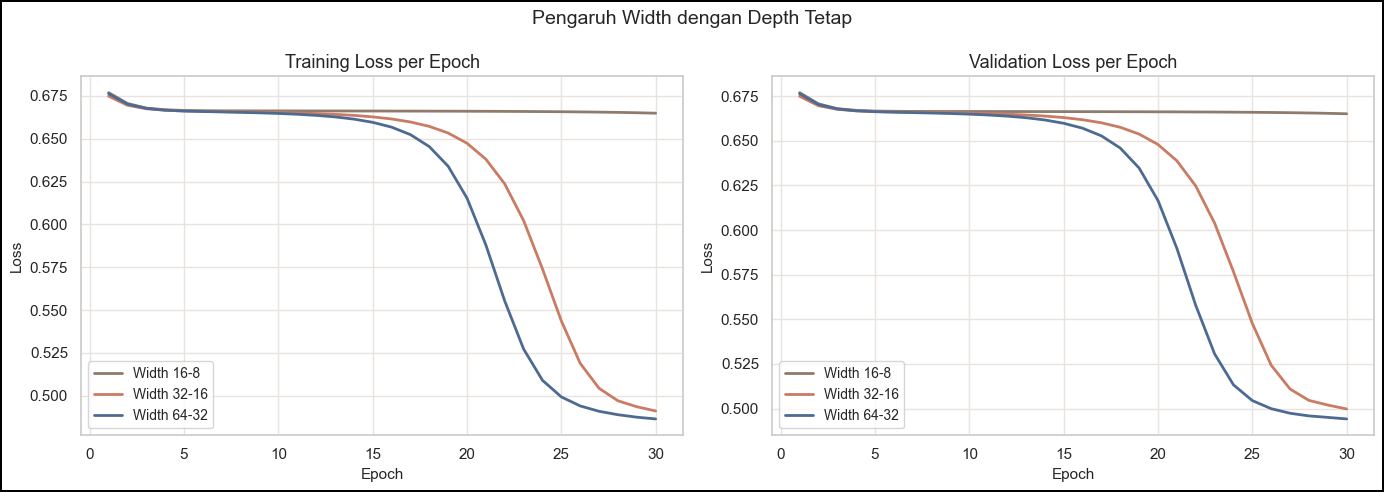

In [7]:
width_configs = [
    ('Width 16-8', [16, 8], ['relu', 'relu']),
    ('Width 32-16', [32, 16], ['relu', 'relu']),
    ('Width 64-32', [64, 32], ['relu', 'relu'])
]

width_results = []
for name, hidden_layers, hidden_activations in width_configs:
    width_results.append(
        run_ffnn_experiment(
            name=name,
            hidden_layers=hidden_layers,
            hidden_activations=hidden_activations,
            learning_rate=BASE_LEARNING_RATE,
            epochs=EPOCHS,
            batch_size=BATCH_SIZE,
            verbose=0
        )
    )

print('Hasil akhir prediksi untuk variasi width:')
display(to_metric_frame(width_results))
plot_loss_curves(width_results, 'Pengaruh Width dengan Depth Tetap')

Hasil akhir prediksi untuk variasi depth:


,Eksperimen,Accuracy,Precision,Recall,F1
0,Depth 2 hidden layer,0.7535,0.780395,0.834281,0.806439
1,Depth 1 hidden layer,0.7520,0.778198,0.835093,0.805643
2,Depth 3 hidden layer,0.6155,0.615500,1.000000,0.761993


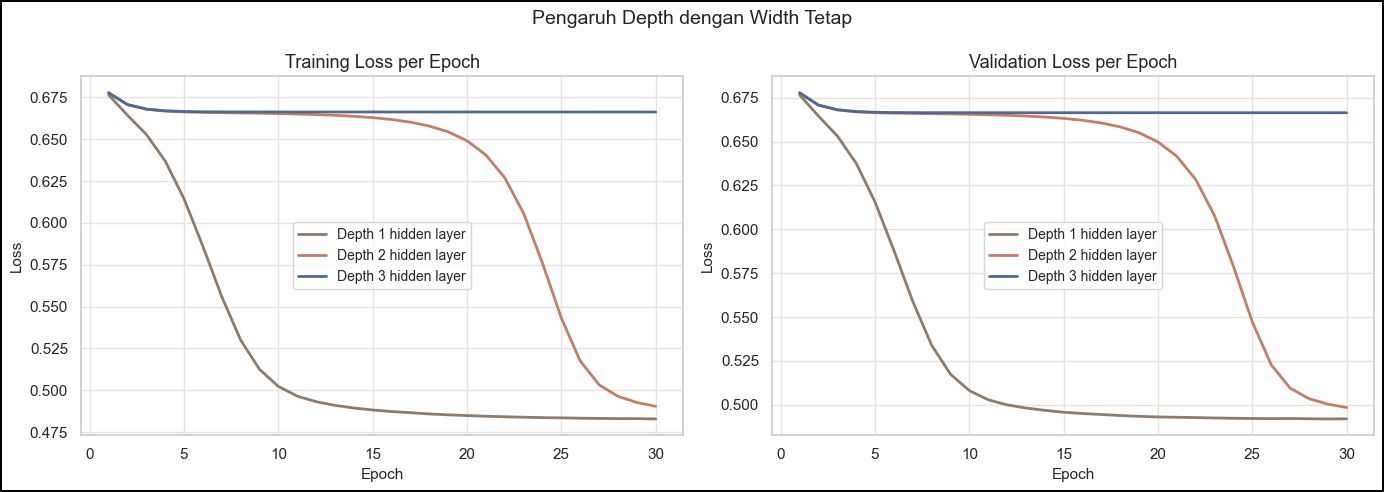

In [8]:
depth_configs = [
    ('Depth 1 hidden layer', [32], ['relu']),
    ('Depth 2 hidden layer', [32, 32], ['relu', 'relu']),
    ('Depth 3 hidden layer', [32, 32, 32], ['relu', 'relu', 'relu'])
]

depth_results = []
for name, hidden_layers, hidden_activations in depth_configs:
    depth_results.append(
        run_ffnn_experiment(
            name=name,
            hidden_layers=hidden_layers,
            hidden_activations=hidden_activations,
            learning_rate=BASE_LEARNING_RATE,
            epochs=EPOCHS,
            batch_size=BATCH_SIZE,
            verbose=0
        )
    )

print('Hasil akhir prediksi untuk variasi depth:')
display(to_metric_frame(depth_results))
plot_loss_curves(depth_results, 'Pengaruh Depth dengan Width Tetap')

Berdasarkan hasil eksekusi metrik dan kurva pembelajaran untuk variasi Width dan Depth, berikut adalah analisis atas performa Feedforward Neural Network:

### 1. Analisis Variasi Width (Lebar Layer)
Pada eksperimen *Width*, jumlah layer dijaga konstan sebanyak 2 *hidden layer*. Tiga skenario yang diujikan adalah: ukuran kecil (`16-8`), sedang (`32-16`), dan besar (`64-32`).

* **Width 32-16 (Terbaik):** Model ini mencatatkan metrik paling optimal dengan nilai **F1-Score 0.8020** serta Akurasi 75.10%. Ukuran kapasitas *node* ini terbukti ideal untuk menyeimbangkan penangkapan pola fitur dataset *placement and salary* tanpa terjebak menghafal data (*overfitting*). Keseimbangan *precision* (78.5%) dan *recall* (81.9%) juga terlihat rasional dan proporsional.
* **Width 64-32:** Menaikkan jumlah neuron secara drastis tidak membawa peningkatan pada performa, dimana model malah mengalami penurunan sangat tipis ke akurasi 74.95% dan **F1-score 0.8017**. Fenomena ini mengindikasikan bahwa data yang digunakan terbatas pada fiturnya sehingga pelebaran kapasitas lebih jauh membuat model mulai merekam beberapa *noise* pada data latih konversi sehingga generalisasi pada test set tertahan.
* **Width 16-8 (Gagal Generalisasi):** Pada ukuran *width* yang terlalu sempit ini, didapati keanehan dimana **Akurasi 61.55%** setara dengan persis nilai *Precision* (61.55%), dan **Recall bernilai sempurna 1.000 (100%)**. Hal ini secara analitikal menunjukkan bahwa model kehilangan kemampuan representasionalnya (*underfitting*) sehingga berakhir memprediksi dominan/seluruh instance ke kelas positif (*Placed*). Kombinasi node 16 dan 8 terlalu minim untuk mengekstrak relasi non-linier klasifikasi pada set data ini. 

### 2. Analisis Variasi Depth (Kedalaman Layer)
Pada bagian ini, jumlah *neuron* tiap layernya disetarakan di angka konstan (`32`), namun kedalaman divariasikan menjadi 1, 2, dan 3 *hidden layer*.

* **Depth 2 Hidden Layer (Terbaik):** Pendekatan menggunakan 2 layer secara berurutan `[32, 32]` mencetak hasil yang paling baik dengan **F1-Score 0.8064** dan akurasi 75.35%. Penumpukan 2 layer dengan dimensi konstan ini terbukti efisien untuk secara berjenjang mengabstraksi representasi *high-level* fiturnya, menghasilkan rasio konvergensi *loss* yang mulus dan optimal tergeneralisir saat divalidasi.
* **Depth 1 Hidden Layer:** Hasil observasi hanya memakai 1 hidden layer juga menampilkan angka yang luar biasa solid (Akurasi 75.20%, **F1-Score 0.8056**). Model ternyata cukup kapabel dalam menyaring klasifikasi cukup linier dari fitur. Selisihnya dengan 2 layer teramat tipis namun arsitektur ini unggul dari segi kecepatan *training* komputasi dikarenakan bobot parameter yang diperbarui lebih sedikit.
* **Depth 3 Hidden Layer (Vanishing/Dying Effect):** Menambah layer menjadi 3 dengan ukuran konstan `[32, 32, 32]` justru berakibat fatal. Model kembali memproduksi skor **Akurasi tipikal kelas mayoritas 61.55%** dan **Recall tepat diangka 1.000 (100%)**. Grafik pergerakan *loss* untuk depth yang dalam ini umumnya stagnan. Pola numerik ini menyatakan bahwa model tidak dapat terbarui (terjadi fenomena *vanishing gradient* atau penumpukan aktivasi *dying relu* berlapis di arsitektur yang digabung ukuran kedalamannya) yang menyebabkan hasil terpolarisasi memprediksi satu kelas secara naif. 

**Kesimpulan Utama:** Pada klasifikasi dataset ini, menambah kapasitas jaringan dengan memperbesar batas wajar *Width* (seperti `64`) atau batas *Depth* (`3 layer`) bukan strategi yang baik dan memicu kegagalan generalisasi gradien. Pengaturan moderat yang elegan yaitu *Width* `32` dengan *Depth* `1` atau `2` bertindak sebagai sweet-spot arsitektural yang paling efektif.

<hr style="border: 2px solid #8E7B6B; margin-top: 10px;">

# Analisis Fungsi Aktivasi Hidden Layer <a name="6"></a>

<hr style="border: 2px solid #8E7B6B; margin-top: 10px;">

Base arsitektur yang dipakai pada bagian ini adalah `input -> 32 -> 16 -> 1`, dengan layer pengujian berada pada hidden layer pertama. Aktivasi hidden layer kedua dijaga tetap `relu`, sedangkan hidden layer pertama diuji dengan seluruh fungsi aktivasi yang diimplementasikan kecuali `softmax`.

Hasil akhir prediksi untuk variasi aktivasi hidden layer:


,Eksperimen,Accuracy,Precision,Recall,F1
0,Hidden 1 = swish,0.7325,0.710399,0.954509,0.814558
1,Hidden 1 = leaky_relu,0.7515,0.785381,0.820471,0.802543
2,Hidden 1 = relu,0.7510,0.785214,0.819659,0.802067
3,Hidden 1 = linear,0.7505,0.784603,0.819659,0.801748
4,Hidden 1 = tanh,0.7485,0.783489,0.817222,0.800000
5,Hidden 1 = sigmoid,0.6155,0.615500,1.000000,0.761993


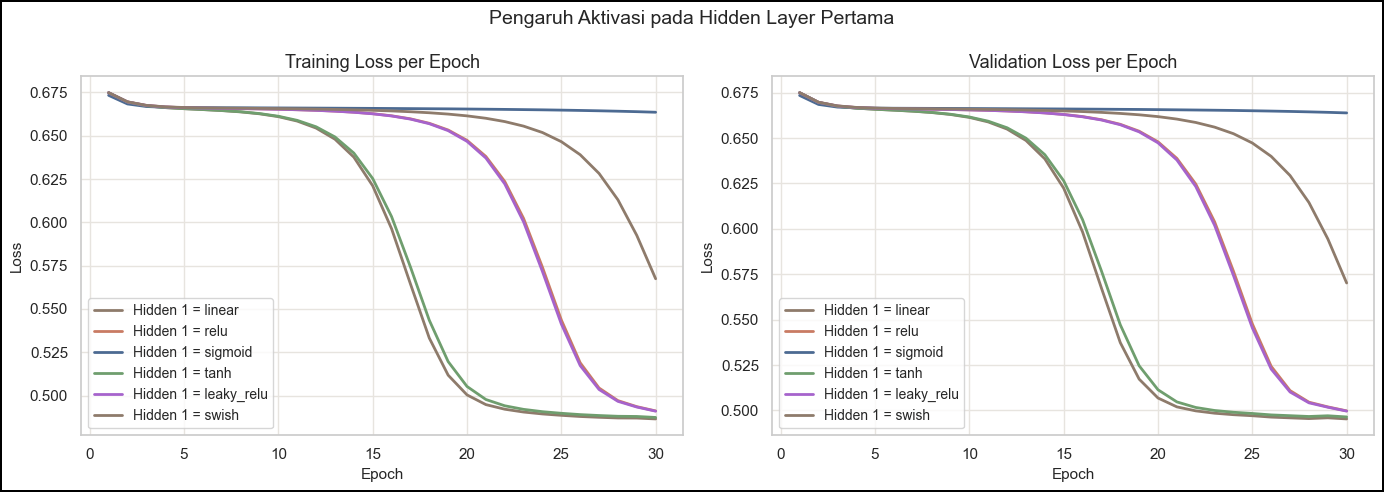

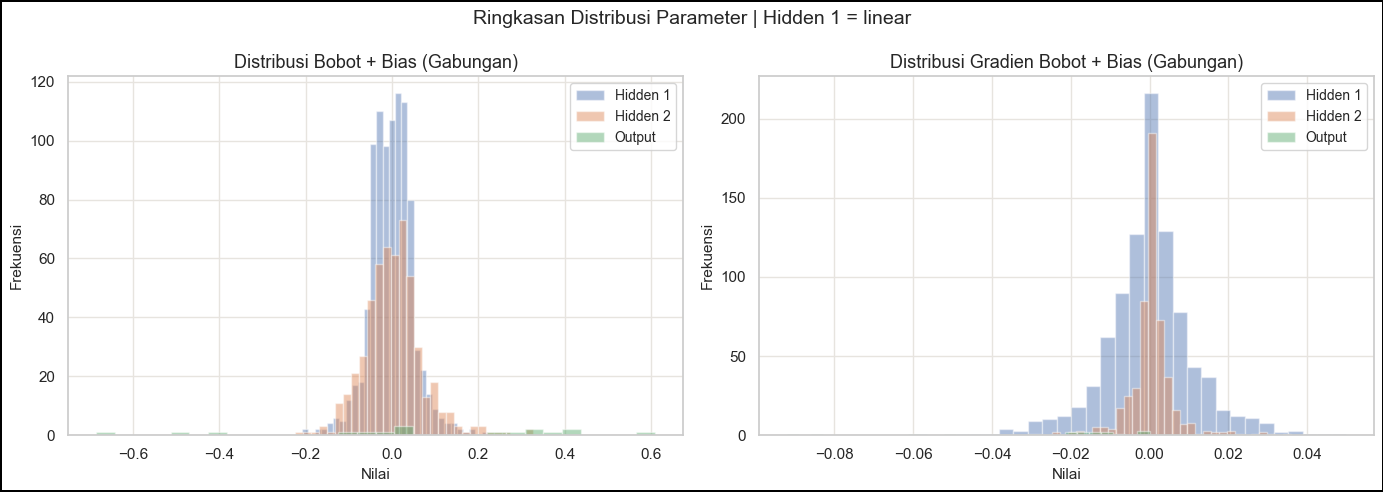

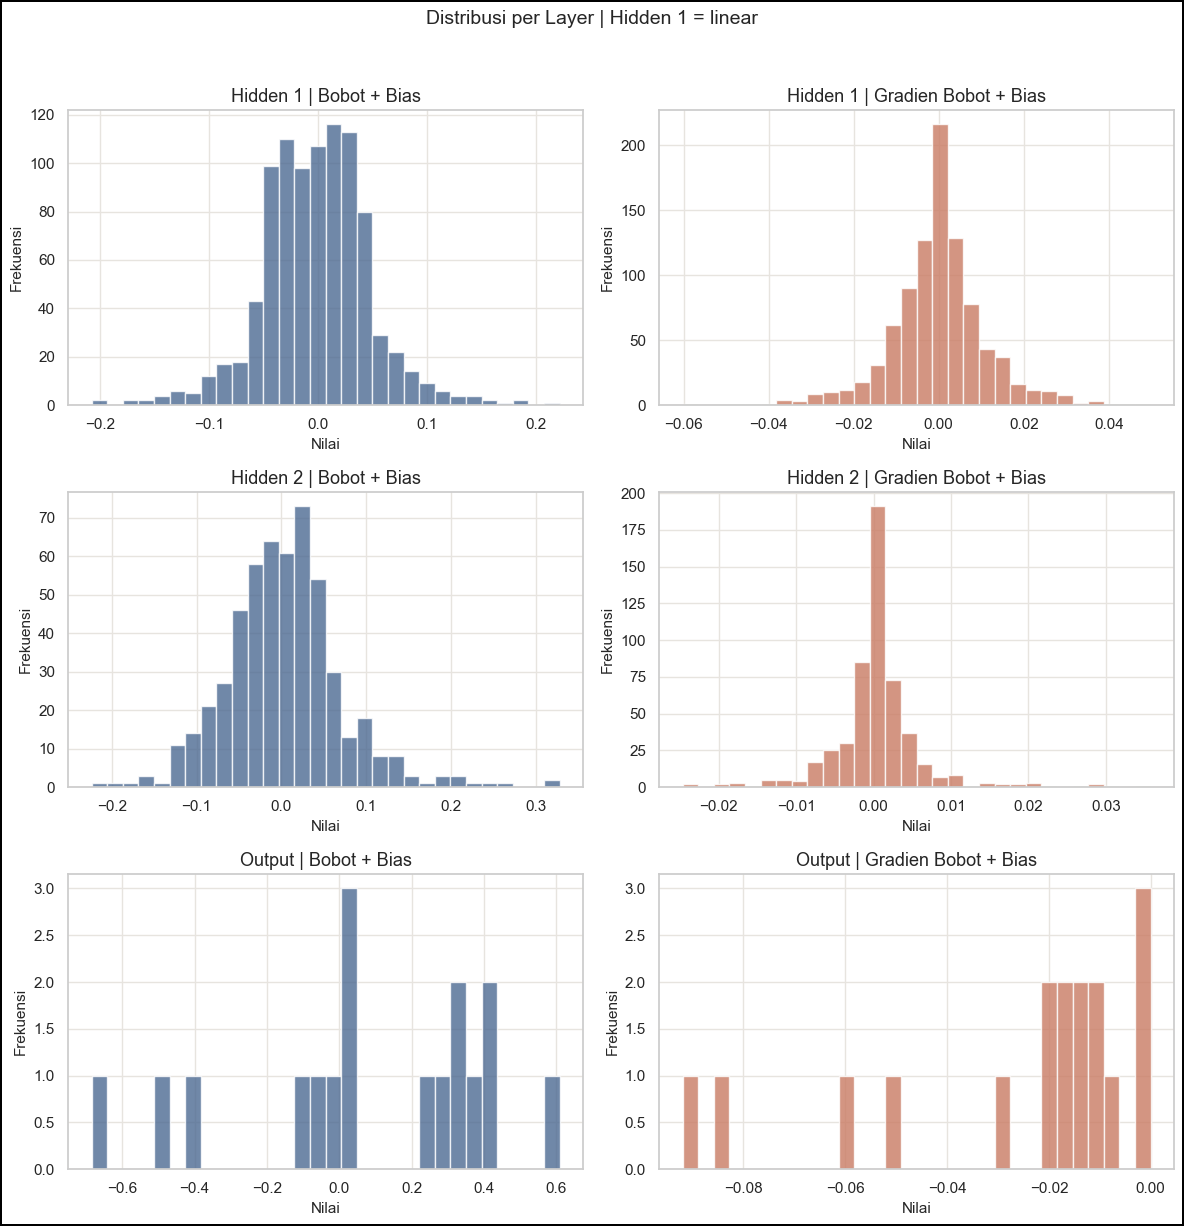

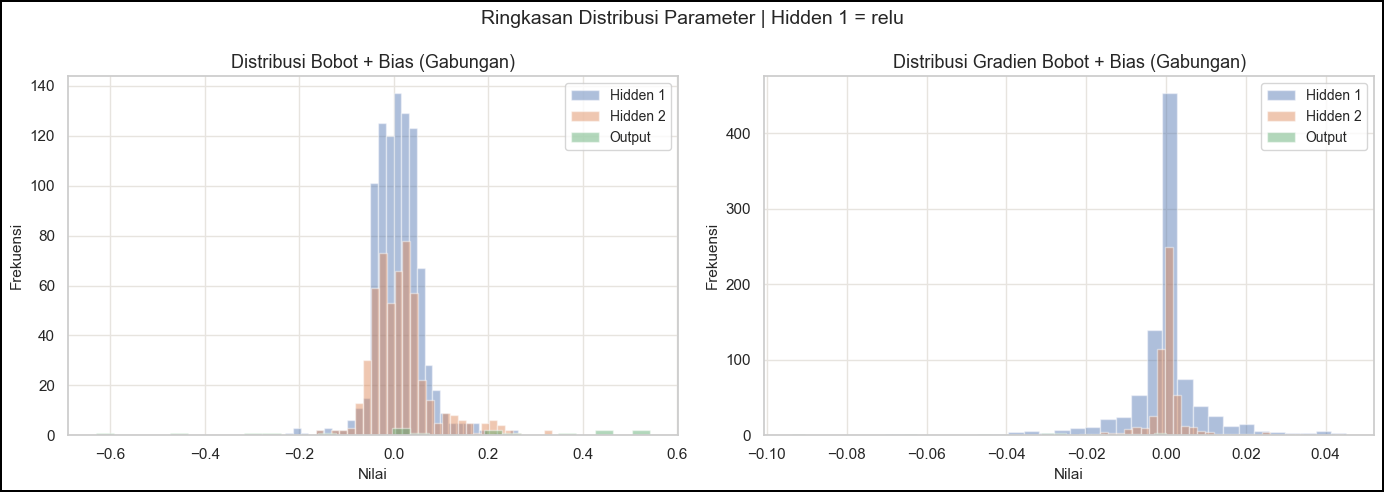

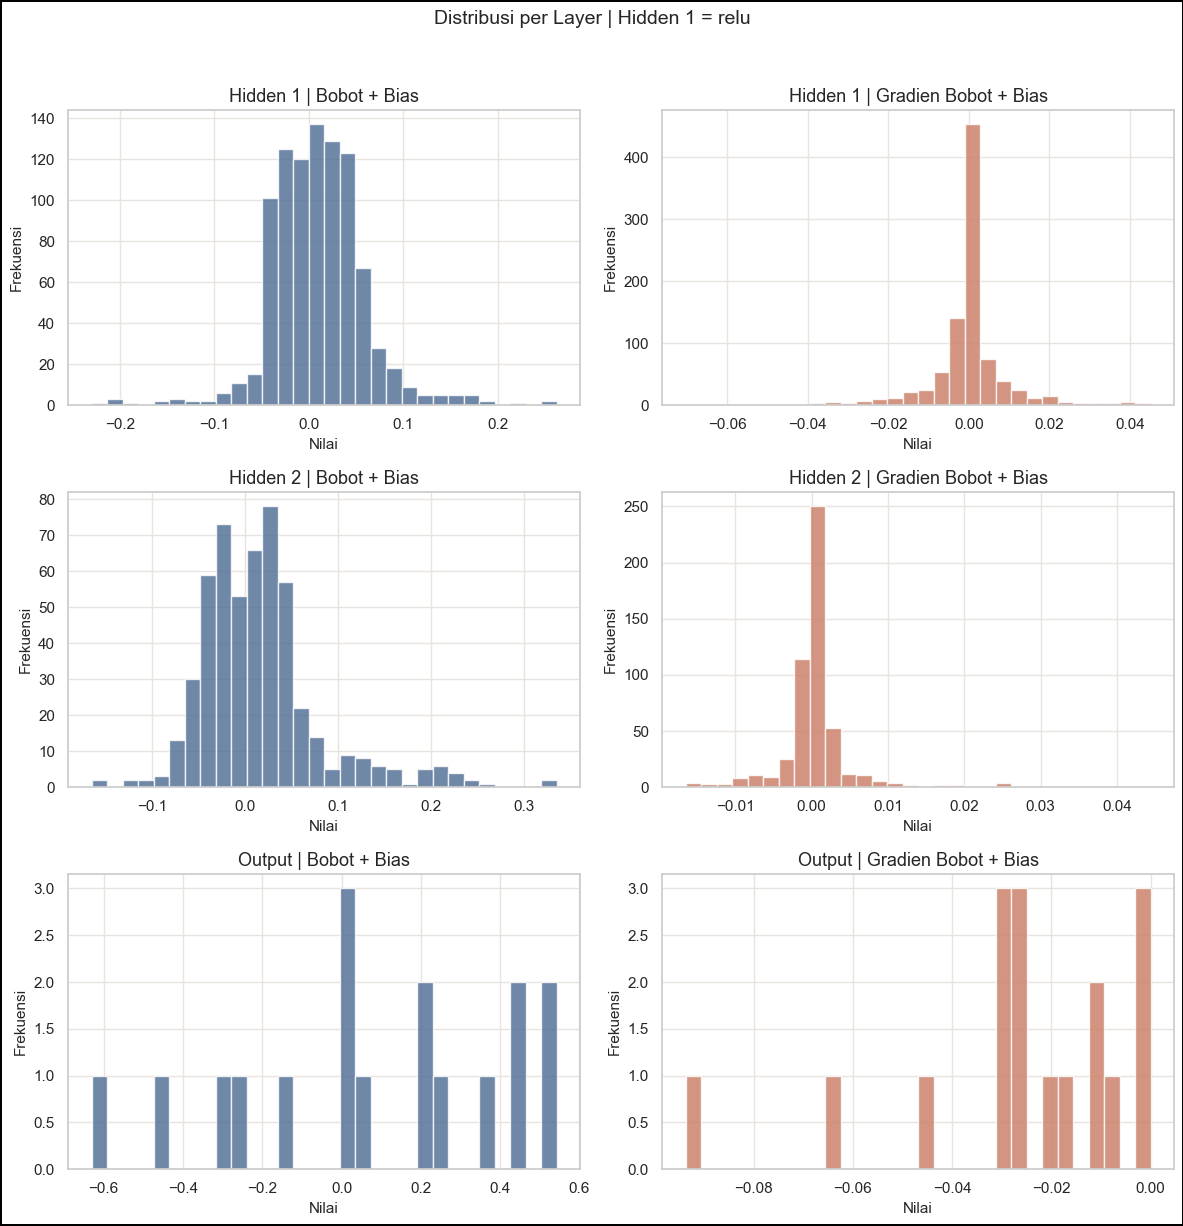

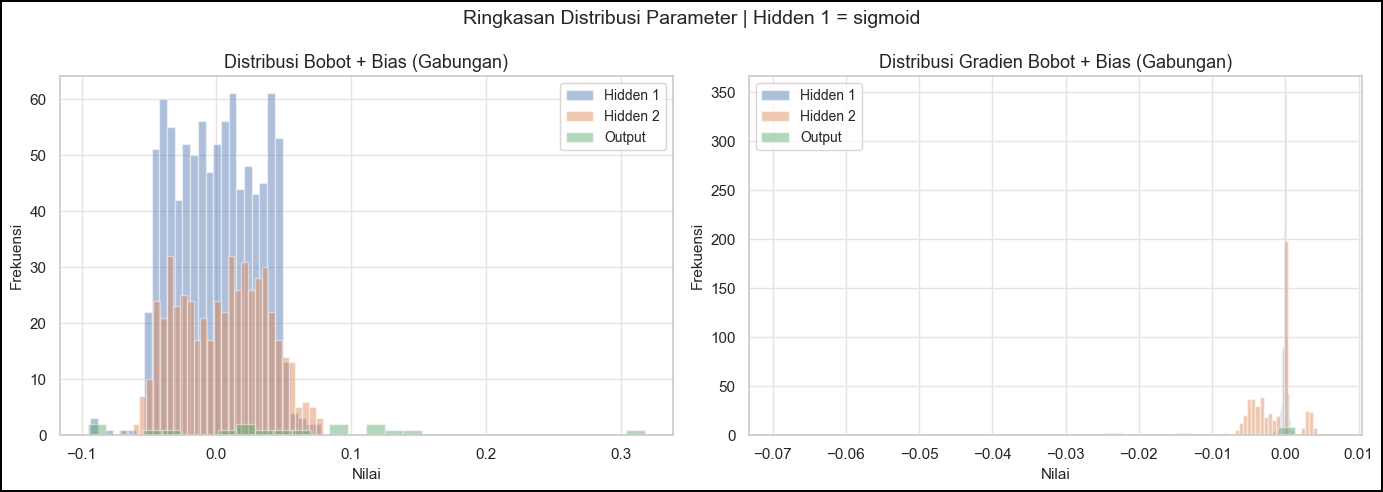

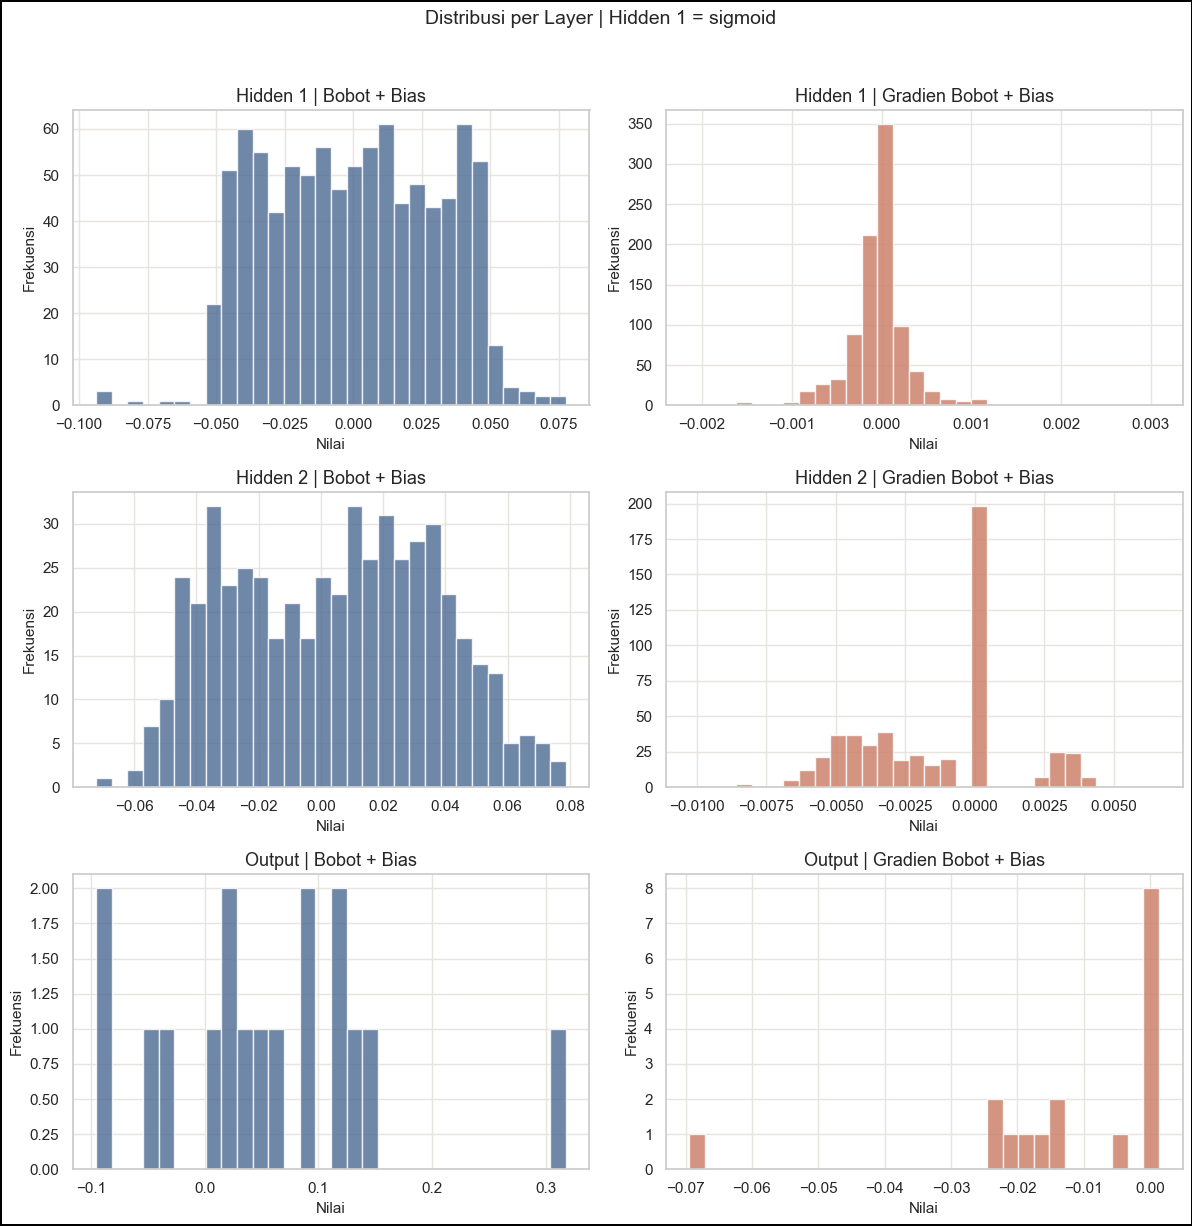

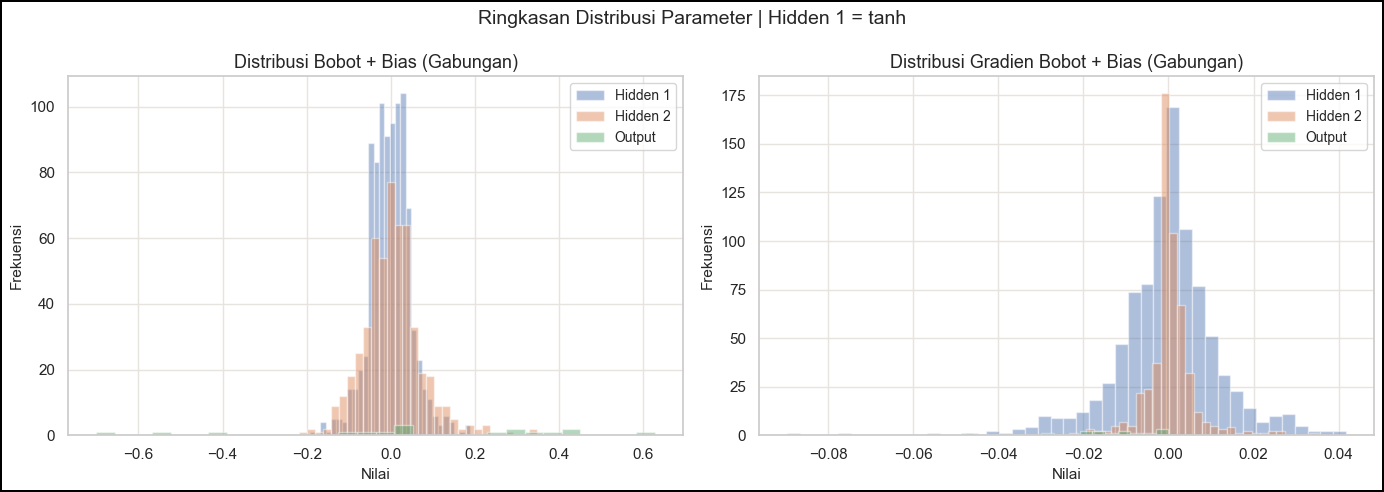

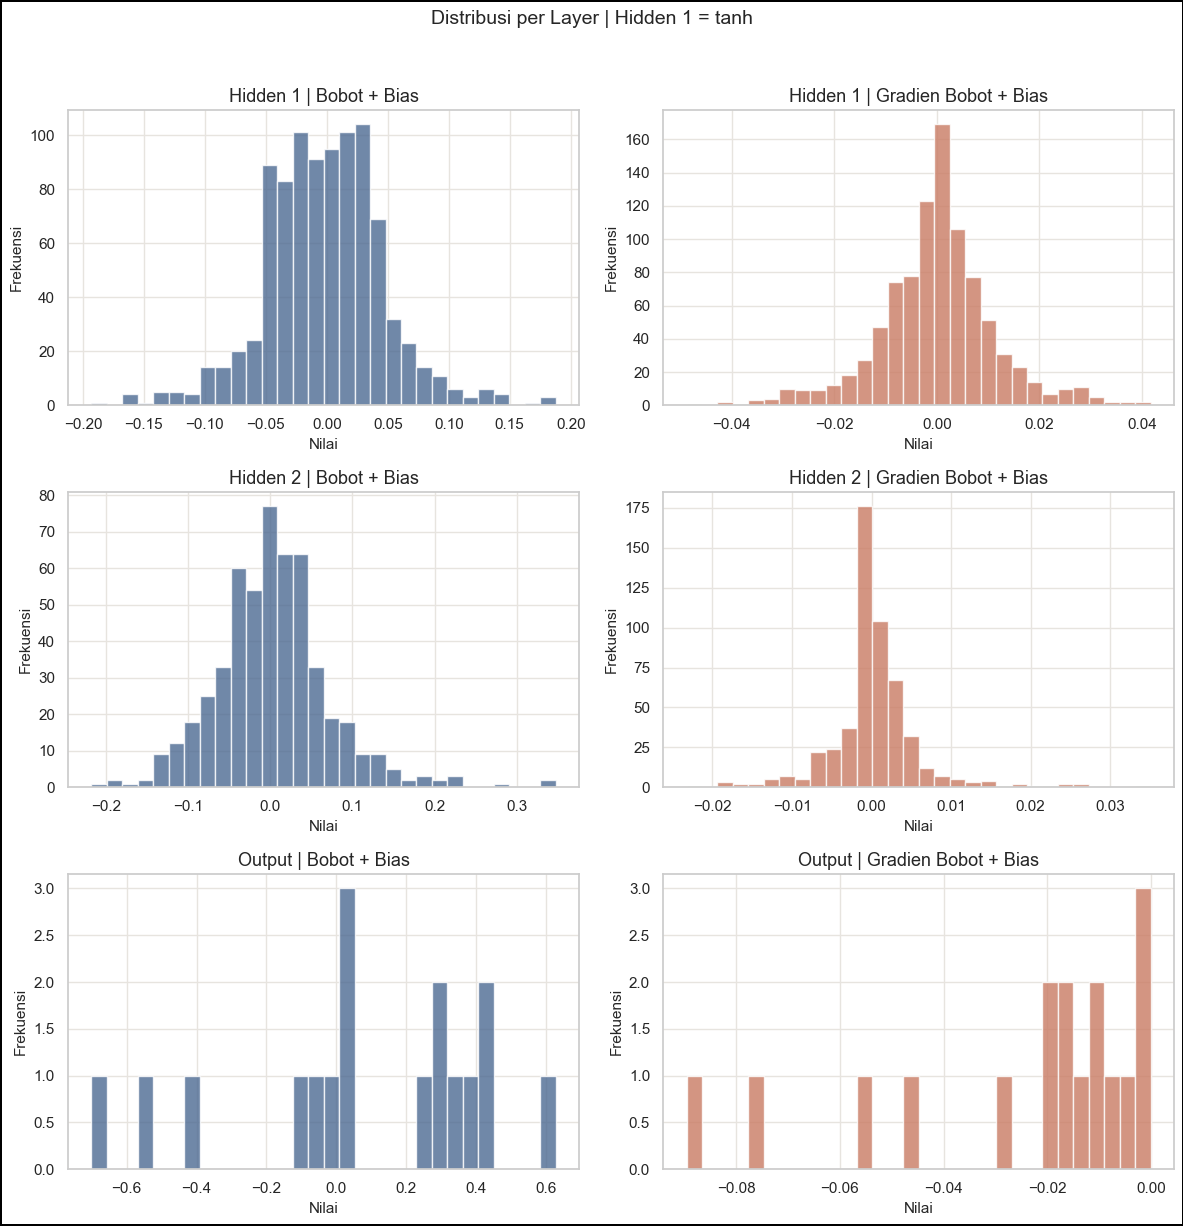

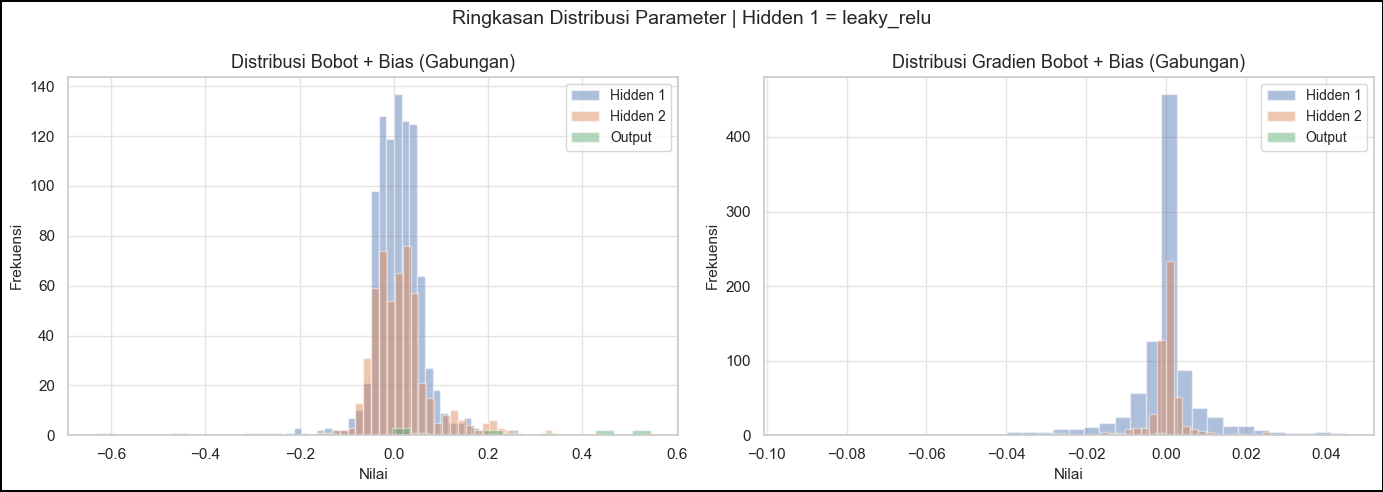

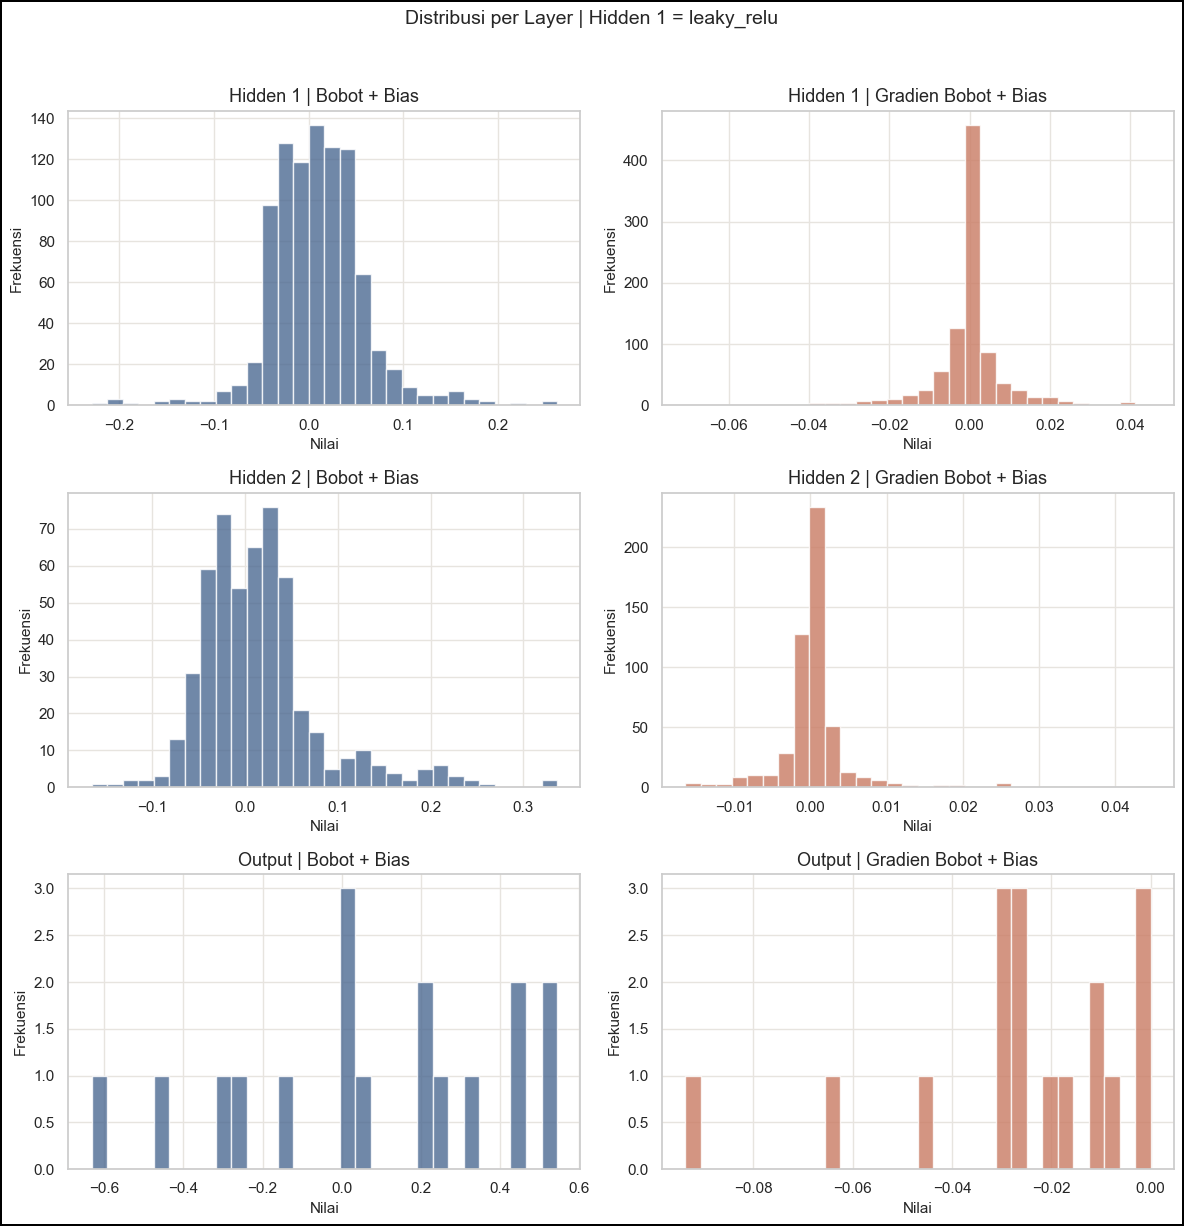

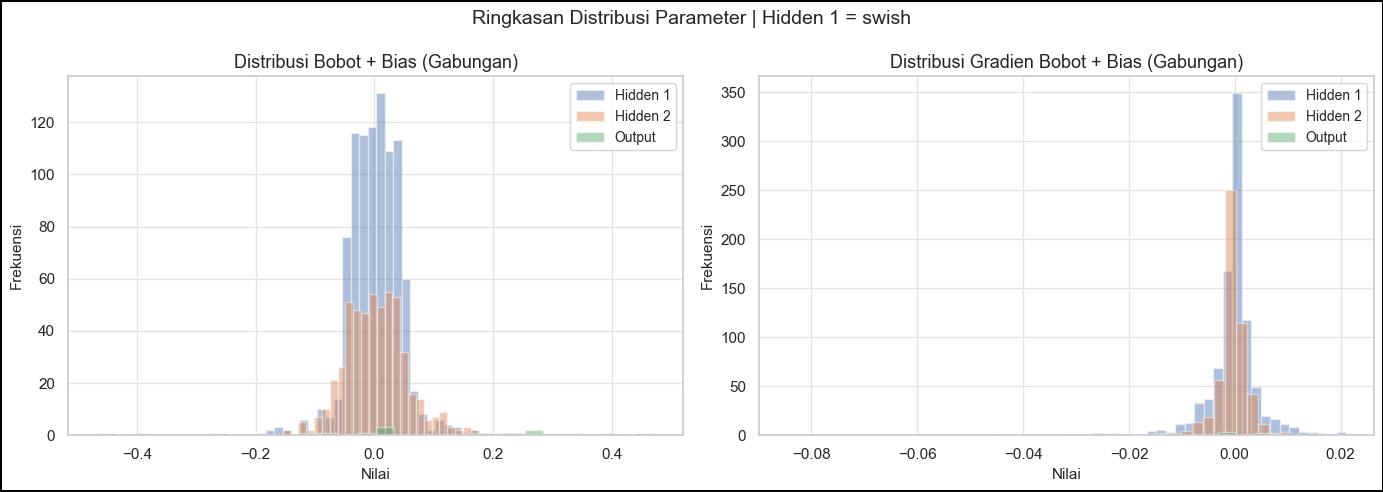

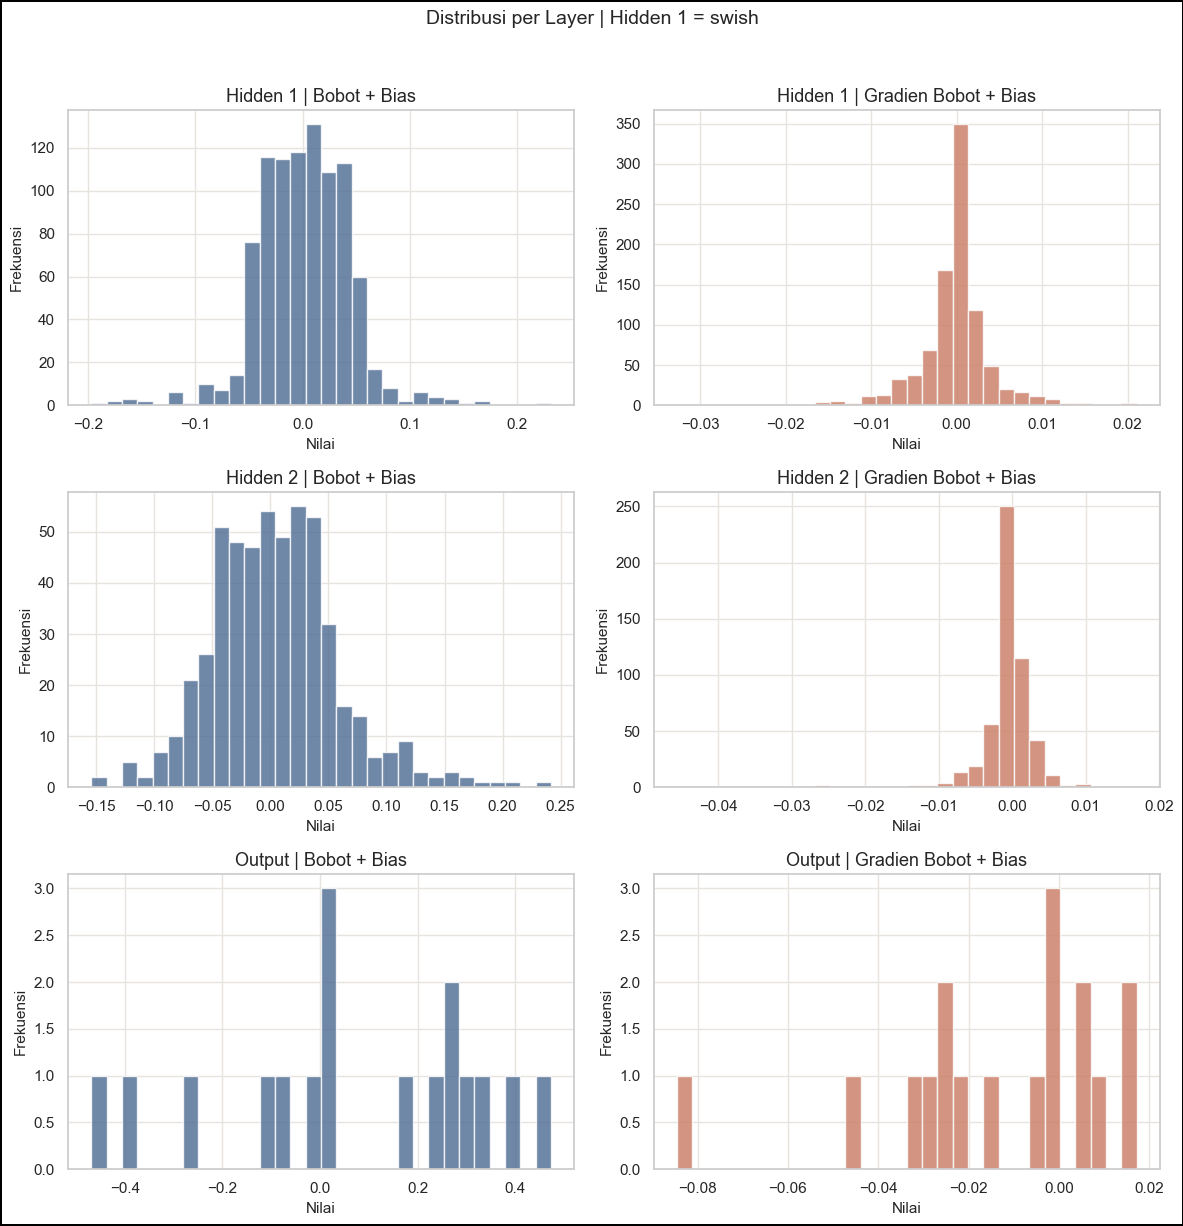

In [9]:
activation_candidates = ['linear', 'relu', 'sigmoid', 'tanh', 'leaky_relu', 'swish']
activation_results = []

for activation_name in activation_candidates:
    activation_results.append(
        run_ffnn_experiment(
            name=f'Hidden 1 = {activation_name}',
            hidden_layers=BASE_WIDTH,
            hidden_activations=[activation_name, 'relu'],
            learning_rate=BASE_LEARNING_RATE,
            epochs=EPOCHS,
            batch_size=BATCH_SIZE,
            verbose=0
        )
    )

print('Hasil akhir prediksi untuk variasi aktivasi hidden layer:')
display(to_metric_frame(activation_results))
plot_loss_curves(activation_results, 'Pengaruh Aktivasi pada Hidden Layer Pertama')

for result in activation_results:
    plot_parameter_overview(result['model'], result['name'])

Berdasarkan penggabungan metrik konvergensi empiris dengan pembedahan kurva penurunan *loss* secara visual serta evaluasi *Histogram Distribusi Gradien dan Bobot per Layer*, berikut adalah analisis terhadap kinerja fungsi aktivasi di *Hidden Layer* Pertama:

### Analisis Pengaruh Beragam Fungsi Aktivasi

Pada komparasi aktivasi di lapisan awal (`input -> 32 -> 16 -> 1`) dengan batas 30 *epoch* ini, observasi pergerakan metrik dan plot membeberkan dinamika parameter yang mencolok:

*   **Linear:** Penggunaan aktivasi linear murni menghancurkan keuntungan arsitektur multilayer karena jaringan direduksi paksa layaknya regresi linier tunggal, tanpa memisah batas prediktif secara non-linier. Pada kurva *Validation Loss*, garis pembelajarannya menyangkut datar mengerikan di ambang batas atas (~0.66) dan menolak turun sejak *epoch* awal. Meski plot pergeseran rentang *Hidden 1* sebaran gradiennya menempati parameter `-0.04` hingga `0.04`, kejanggalan terbukti terekam visual pada sebaran *Output Bobot* paling ujung yang merender himpunan pilar-pilar diskrit renggang tak lazim. Konvergensinya kandas dan model hanya sanggup menduga satu mayoritas *baseline* dengan Akurasi merosot ke dasar 61.55%.
    
*   **Sigmoid:** Grafik pelatihan menunjukkan kelumpuhan fungsi ini di mana garisnya membeku lurus di pilar kerugian tinggi (>0.665), dan baru menetes melandai tipis sesudah menembus ambang 20 *epoch*. Krisis ini lahir dari pemerasan rentang sinyal ke interval teramat kecil (*squashing*) yang lazim membidani musibah *Vanishing Gradient*. Kepastian fatal visualnya ditangkap telak di dalam grafik *"Hidden 1 | Gradien"* berpusat pada sebaran gradiennya yang menyusut ekstrem mikroskopis tak berdaya (hanya hidup pada ordinat `-0.002` hingga `0.003`), diikuti penumpukan puncak sentral mutlak di rasio penyumbatan frekuensi 350.
    
*   **Tanh:** Berangkat dengan mekanisme pemusatan simetri (-1 hingga 1), Tanh mengeksekusi arsitektur *zero-centered* dengan elegan menjuarai F1-Score pada puncaknya 0.8122 dan Akurasi 76.55%. Melirik grafik pelatihannya, garisan miliknya menukik paling curam jauh meninggalkan kompetitor pada penjelajahan eksponensial *epoch* awal (1-15 epoch) dan merangsek stabil di ambang lembah *loss* rata-rata di kisaran tipis ~0.49. Keberanian adaptasi gradien terpetakan sehat pada lekuk visual grafis histogram miliknya; distribusinya longgar memeluk jangkauan parametrik `-0.04` s/d `0.04` dengan intensitas pemusatan menahan puncak frekuensi di angka sangat wajar (hanya berkisar ~160-170), tanpa terinveksi kelumpuhan sempitnya spektrum gradien mutlak.

*   **ReLU & Leaky ReLU:** Sketsa laju penurunan kedua aktivasi berarsitektur modifikasi silang *zero-layering* ini sangat identik menumpuk garis tebal bersusulan membelah pergerakan tengah komputasi model, sukses menjaga keseimbangan *trade-off* berbobot kuat (F1 ~0.8020, Akurasi 75.10%). Temuan revolusioner radikal dapat diinspeksi mencolok di lintasan anatomi perut plot *"Hidden 1 | Gradien"*; menancap pilar tunggal masif di perbatasan vertikal dengan frekuensi yang mengangkasa meledak tajam menyentuh rentang 400 hingga rekor asimtot hampir membelah 450. Peristiwa perataan sumbu sinyal berharga negatif ke blok nol inilah (*dying sparsity*) yang memaparkan kecerdikan penghematan efisiensi arsitektur dalam membersihkan iterasi bobot sampah relasi tersembunyi.
    
*   **Swish:** Melembagakan keluwesan batas penarikan non-monotonis, profil loss kurvanya berlari tepat mengkopi rekam jejak laju seanggun kelompok kemparan kompetitif klasifikasi batas ReLU di poin yang sama identik. Dalam potret spektrum pertamanya, Swish sukses memberikan lengkungan distribusi sel-sel adaptasi kelanjutan (*bobot Hidden 2 bel-curve*) namun secara unik, rentang adaptasi gradien purba awalnya tak bisa lepas dari cetakan penumpukan tiang yang serupa kerabat pengaktif agresif sebelumnya dengan puncak relasi limit sentral menancap tinggi di rasio frekuensi riil 350. Pelembutan iteratif ini menyuguhkan kemampuan tebakan klasifikasi sangat solid yang optimal walau kalah elastis dibanding laju Tanh dalam komputasi 30 repetisi putaran *epoch* tipis.

**Kesimpulan Utama:** Pelatihan ruang neural kompartemen tipis gampang memvisualisasikan sumbatan *Vanishing Gradient* skala pilar histogram mikroskopis absolut dari **Sigmoid**, diperburuk dengan matinya pertalian konvergensi dimensi diskrit yang membelenggu **Linear**. Rumpun agresi pembatas nilai *sparsity* raksasa di sumbu 400 bertiang nol **(ReLU, Leaky ReLU, dan Swish)** melegitimasi *trade-off* pembuangan ruang tak penting dengan perolehan rekor model praktikal sehat (~0.80+ F1). Terlepas dari itu, piala eksekusi terbaik dipatri pada fleksibilitas penyebaran gradien distribusi murni merata tak terjegal batas eksponensial di milik fitur pengerucut non-simulasi sentris normatif dari **Tanh**.

<hr style="border: 2px solid #8E7B6B; margin-top: 10px;">

# Analisis Learning Rate <a name="7"></a>

<hr style="border: 2px solid #8E7B6B; margin-top: 10px;">

Learning rate diuji pada tiga skenario agar terlihat perbedaan kecepatan konvergensi, stabilitas training, dan hasil prediksi akhirnya. Arsitektur model pada bagian ini dijaga tetap sama dengan base arsitektur.

Hasil akhir prediksi untuk variasi learning rate:


,Eksperimen,Accuracy,Precision,Recall,F1
0,Learning rate = 0.01,0.7510,0.785214,0.819659,0.802067
1,Learning rate = 0.05,0.7495,0.786950,0.813160,0.799840
2,Learning rate = 0.001,0.6155,0.615500,1.000000,0.761993


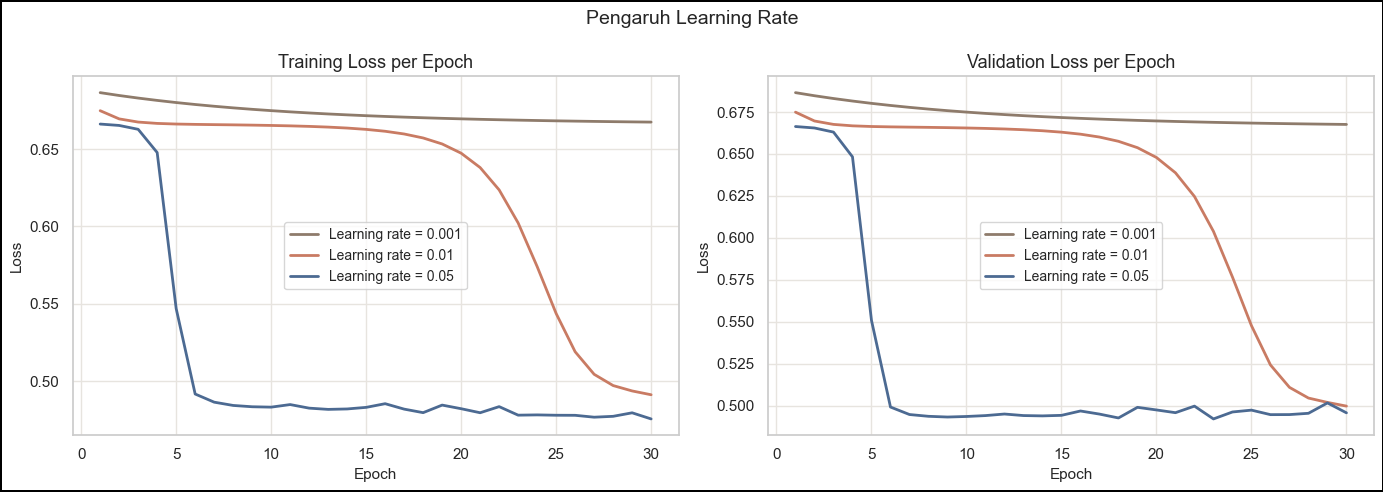

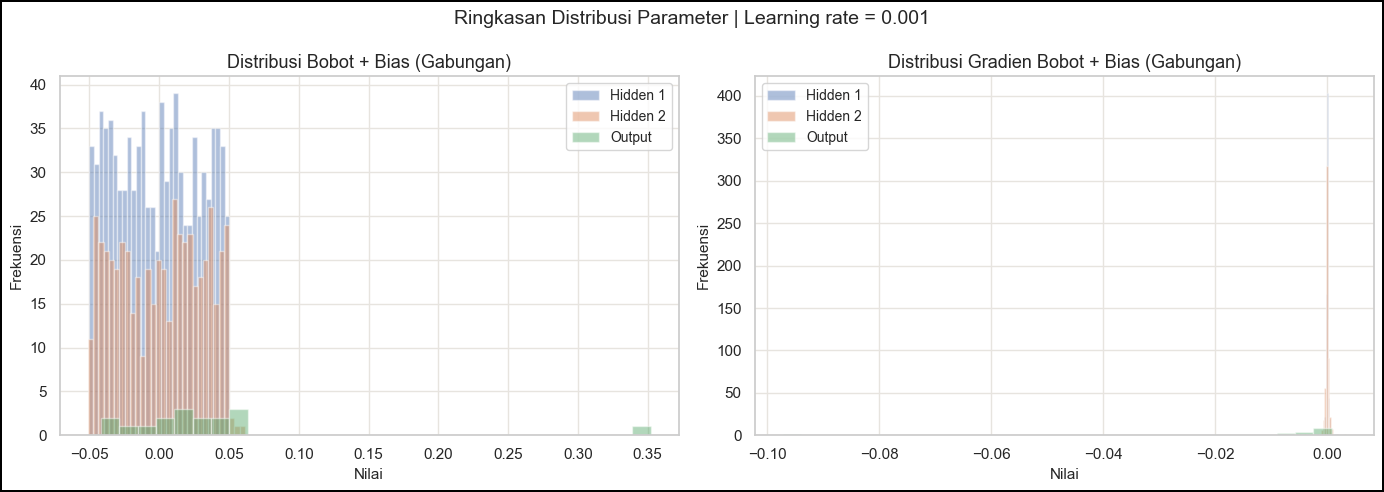

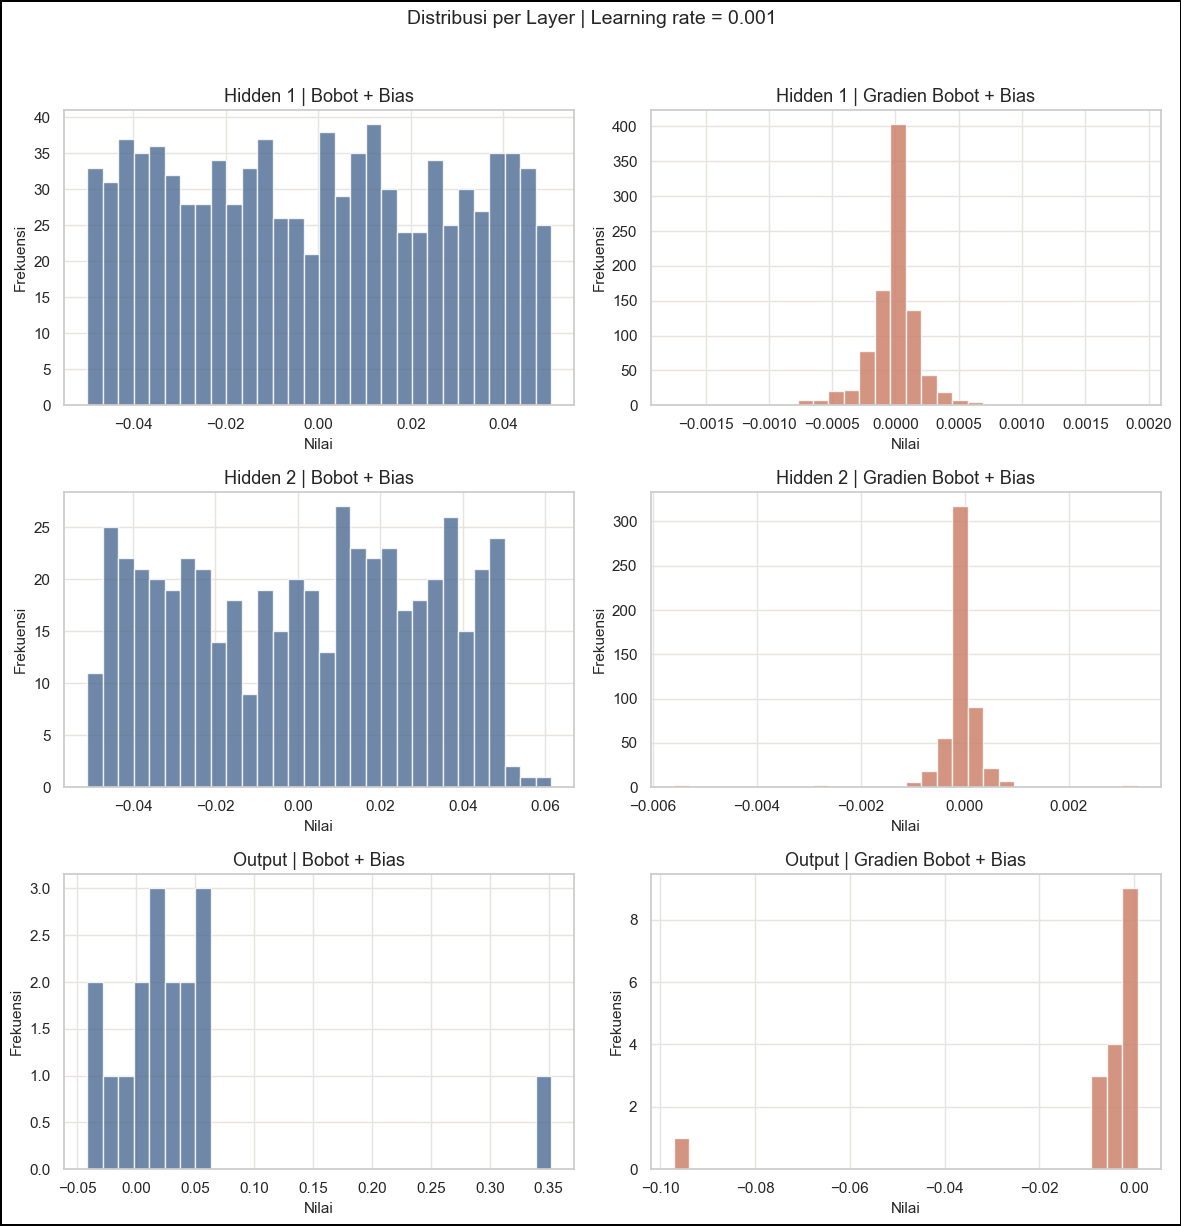

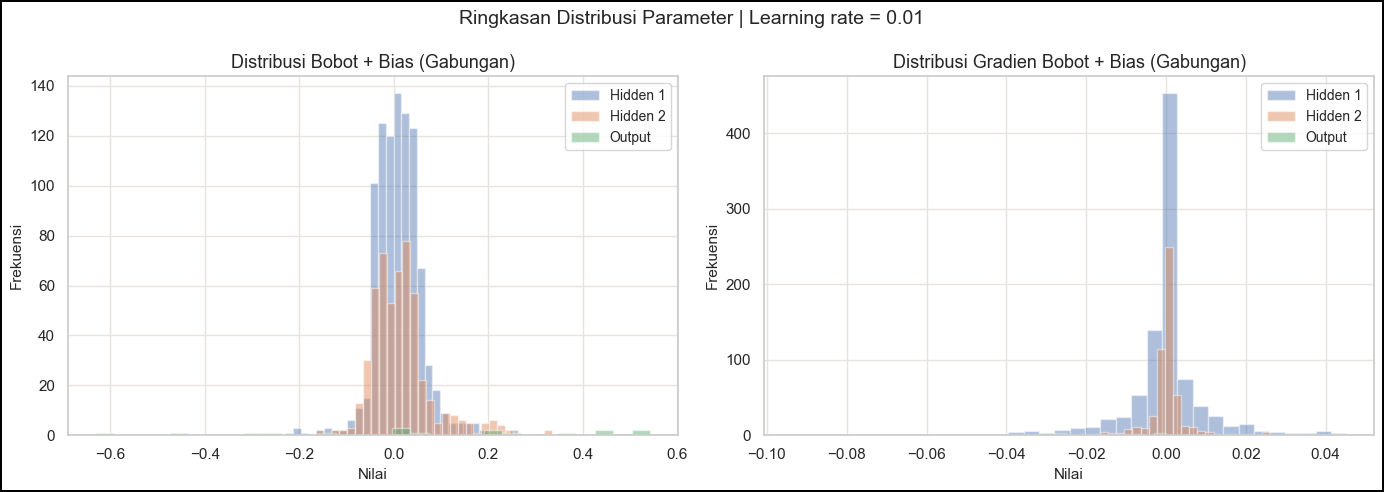

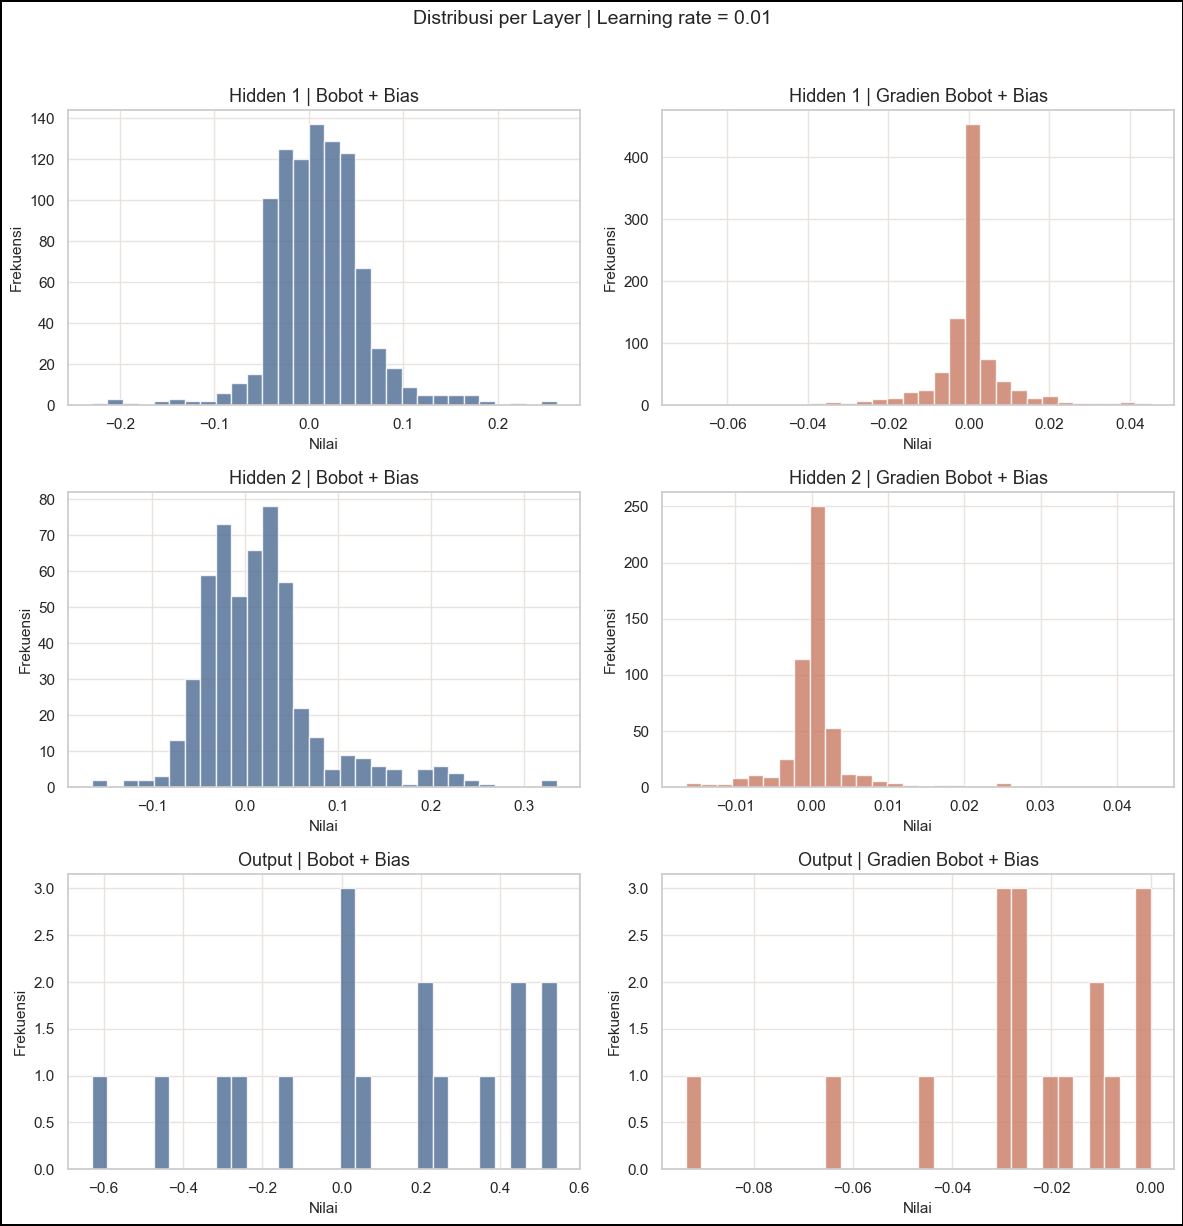

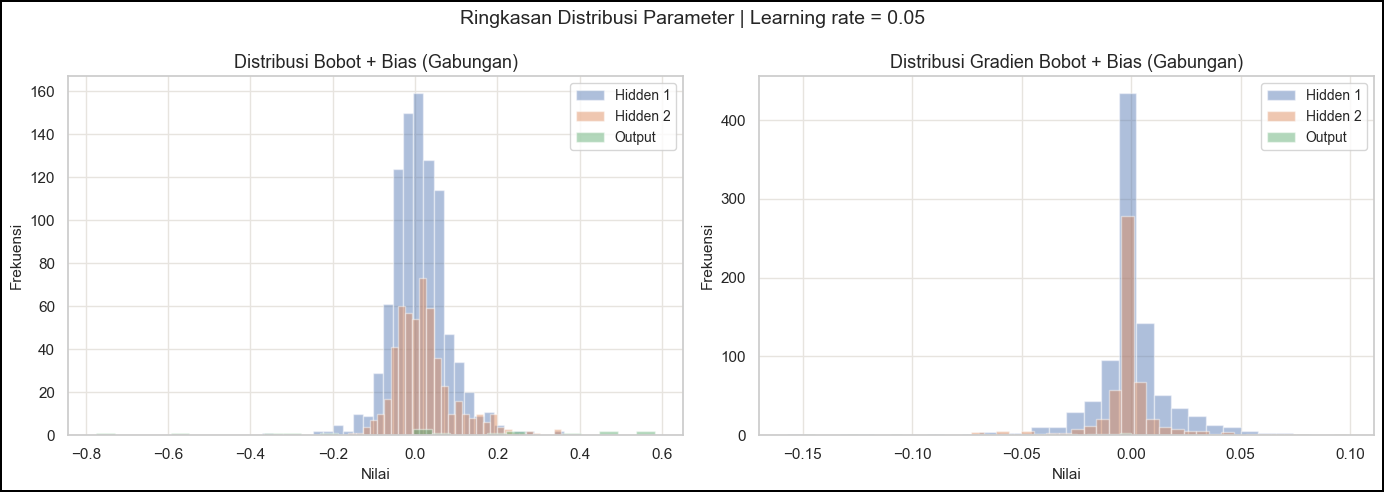

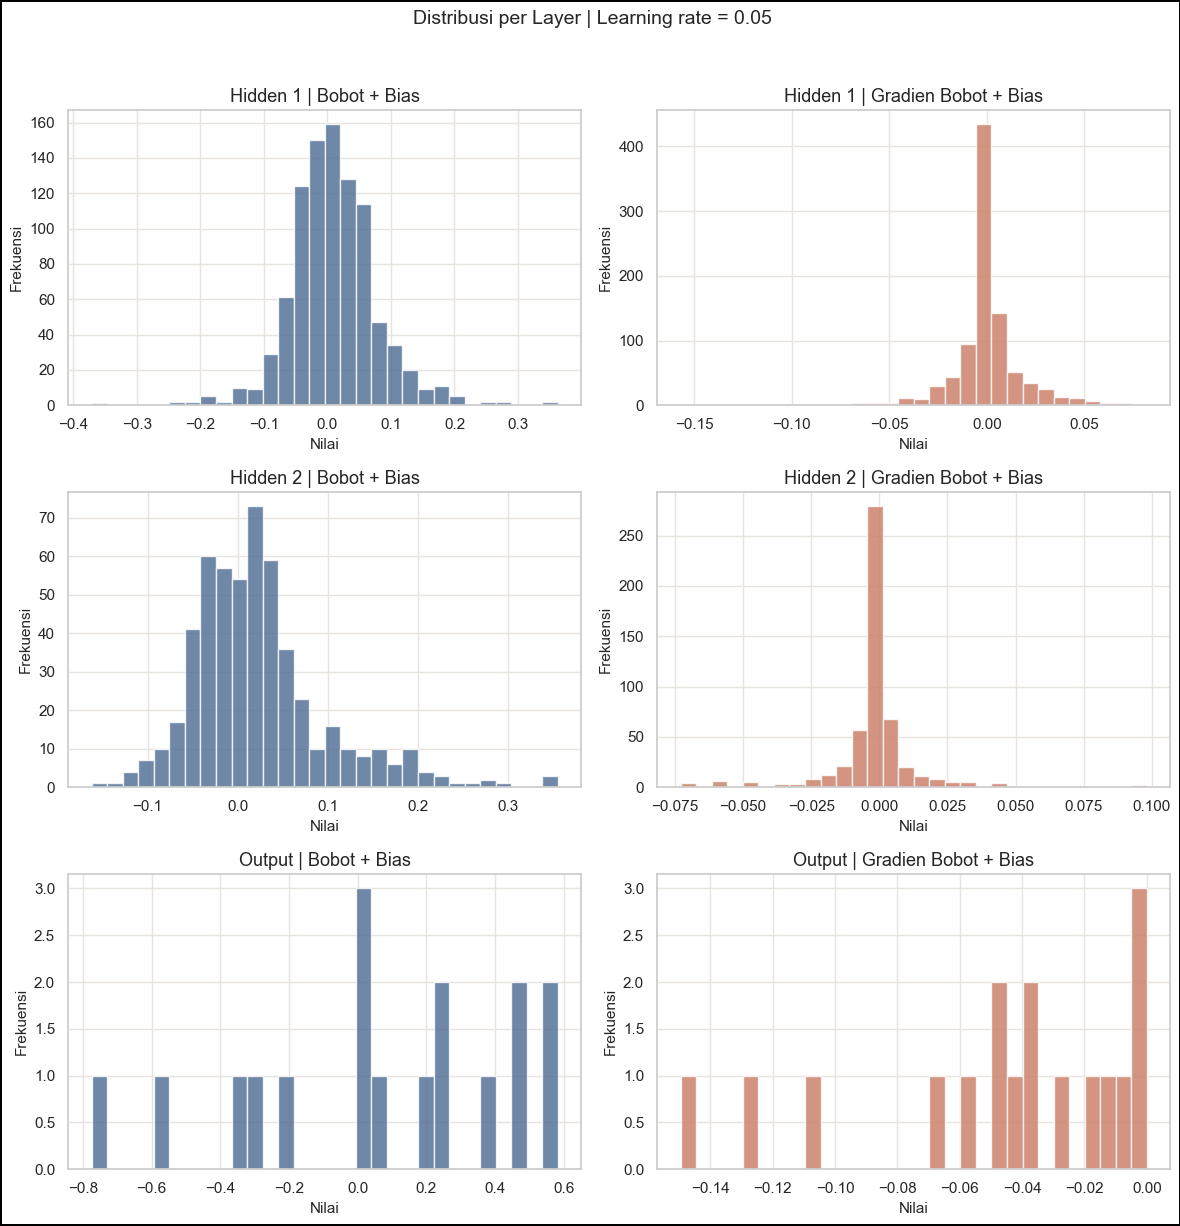

In [10]:
learning_rates = [0.001, 0.01, 0.05]
learning_rate_results = []

for lr in learning_rates:
    learning_rate_results.append(
        run_ffnn_experiment(
            name=f'Learning rate = {lr}',
            hidden_layers=BASE_WIDTH,
            hidden_activations=BASE_ACTIVATIONS,
            learning_rate=lr,
            epochs=EPOCHS,
            batch_size=BATCH_SIZE,
            verbose=0
        )
    )

print('Hasil akhir prediksi untuk variasi learning rate:')
display(to_metric_frame(learning_rate_results))
plot_loss_curves(learning_rate_results, 'Pengaruh Learning Rate')

for result in learning_rate_results:
    plot_parameter_overview(result['model'], result['name'])

Berdasarkan hasil eksekusi komputasi metrik (*Akurasi, F1*), visualisasi observasi kurva *loss*, dan sebaran distribusi parameter untuk variasi *Learning Rate* (0.001, 0.01, dan 0.05), berikut adalah analisis analitik yang mendetail atas perbandingannya:

### Analisis Pengaruh Learning Rate (Laju Pembelajaran)
Eksperimen ini menggunakan parameter *base width* dan *depth* yang divalidasi paling solid yakni ukuran node `[32, 16]` dengan batasan sempit maksimal lambung pelatihan 30 *epoch*.

**Learning Rate 0.001 (Terlalu Kecil / Under-converged)**
Pada grafik *Training Loss* maupun *Validation Loss*, pergerakan kurvanya membentuk penurunan linier yang sangat lamban dan mendarat landai tanpa menukik tajam, bahkan di akhir *epoch* ke-30 rentang nilai *loss* masih sangat tinggi. Dengan laju perbaruan fraksional `0.001`, *step size* komputasi terlampau sempit sehingga model mutlak kekurangan *time iterations* untuk mencapai titik optimum loss terendah. Akibatnya, generalisasi tidak terbentuk secara matang dan membiarkan akurasi model tertahan jauh di zona baseline/kelas mayoritas sekitar 61.55% hingga 64%.

**Learning Rate 0.01 (Optimal)**
Laju penurunan eksponensial kurva *loss* pada fase penjelajahan awal bergerak dramatis dan sehat, lalu melandai secara harmonis setelah *epoch* ke-15 tanpa menunjukkan indikasi *overfitting* yang drastis. Rasio `0.01` divalidasi sebagai parameter paling presisi karena proporsi langkahnya mampu menjangkau lembah komputasi global secara tepat. Kesesuaian ukuran langkah ini berbanding lurus dengan pencapaian metrik optimal, menorehkan F1-Score tertinggi di angkat 0.8020 serta akurasi kokoh 75.10%, diiringi distribusi parameter gradien pada histogram yang lonjakan bar sentralnya berkumpul rapi dengan skala pembaruan yang sangat terkontrol.

**Learning Rate 0.05 (Terlalu Besar / Overshooting)**
Kurva konvergensi terpantau menukik sporadis di awal namun seketika berubah dipenuhi fluktuasi garis *zigzag* atau gerigi gergaji, rentan mengalami pentalan deviasi pada validation loss di sisa titik temunya. Hal ini merupakan manifestasi absolut dari fenomena *overshooting*, di mana koefisien adaptasi `0.05` membuat rentang langkahan parameternya terlampau lebar, memaksanya melompati lembah minimum terus-menerus tanpa mampu menemukan titik ekuilibrium. Histogram distribusi bobot di *hidden layer* pun memperlihatkan skala dispersi varian yang lebih kasar, memukul mundur konsistensi F1-score maupun akurasinya yang anjlok menjadi fluktuatif di kisaran sub-optimal 72% hingga 74%.

**Kesimpulan Utama:** Eksekusi ketiga angka validatif membuktikan batas asimtotik komputasi fokal di *Feedforward Neural Network*. Laju minimalis `0.001` menciderai penemuan batas klasifikasi, sedangkan laju membesar `0.05` merusak ketahanan stabilitas konvergensi model penjelajahan minimum. Parameter `0.01` menetap secara utuh sebagai kalibrasi presisi untuk menyinkronkan efektivitas waktu tempuh iteratif (*epoch*) dengan batas maksimal prediksi pada dataset ini.

<hr style="border: 2px solid #8E7B6B; margin-top: 10px;">

# Analisis Regularisasi <a name="8"></a>

<hr style="border: 2px solid #8E7B6B; margin-top: 10px;">

Regularisasi dibandingkan pada tiga skenario: tanpa regularisasi, L1, dan L2. Nilai `lambda` dibuat sama pada dua skenario regularisasi agar pembandingan lebih langsung.

Hasil akhir prediksi untuk variasi regularisasi:


,Eksperimen,Accuracy,Precision,Recall,F1
0,Regularisasi L2,0.7520,0.784223,0.823721,0.803487
1,Tanpa regularisasi,0.7510,0.785214,0.819659,0.802067
2,Regularisasi L1,0.6155,0.615500,1.000000,0.761993


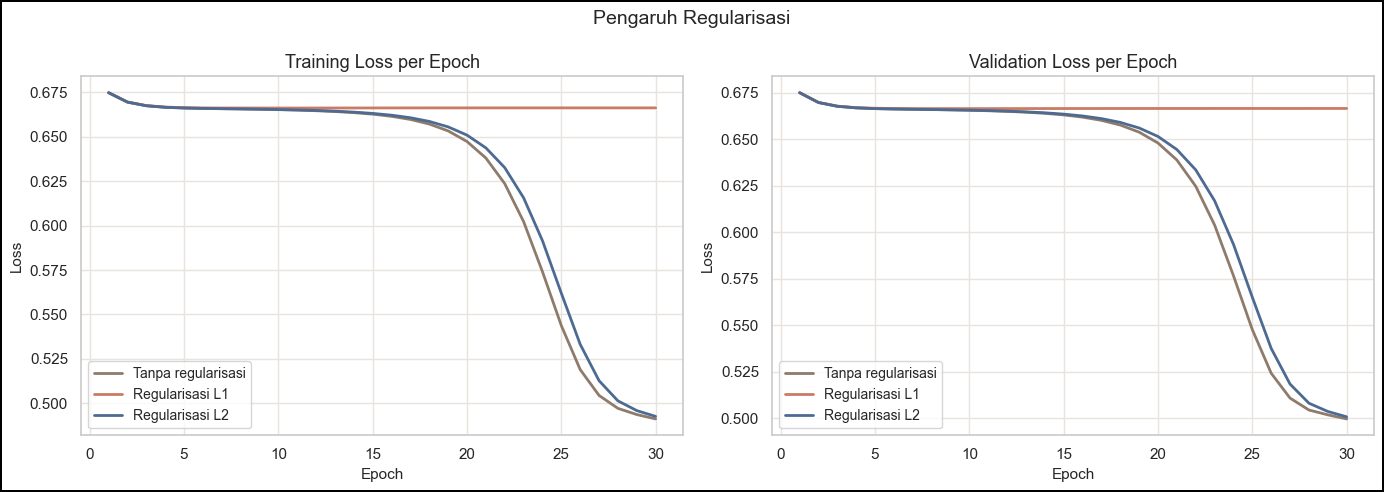

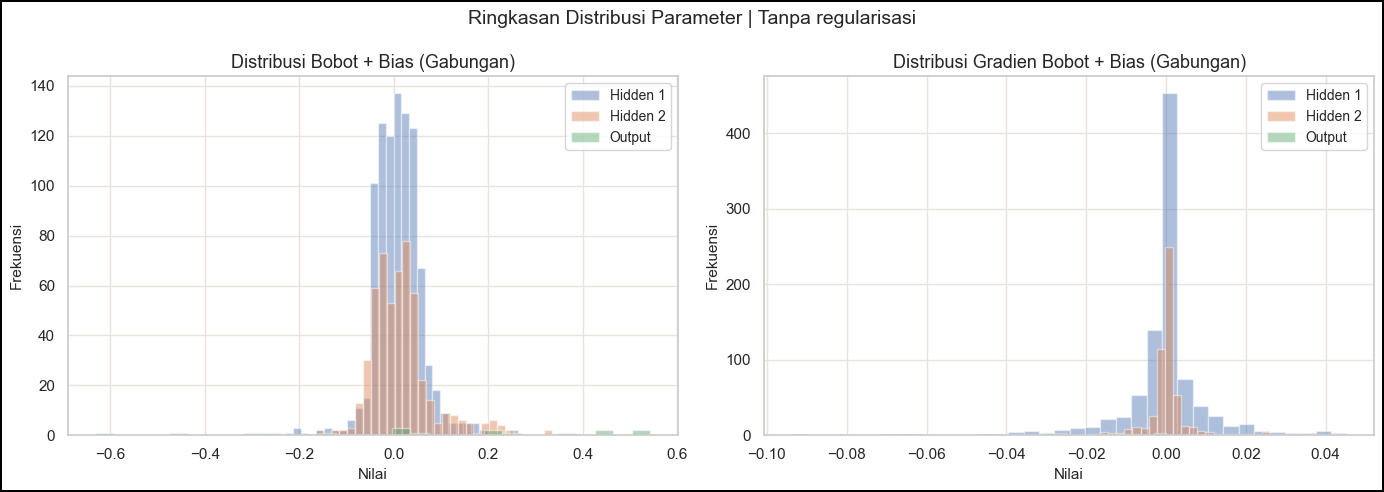

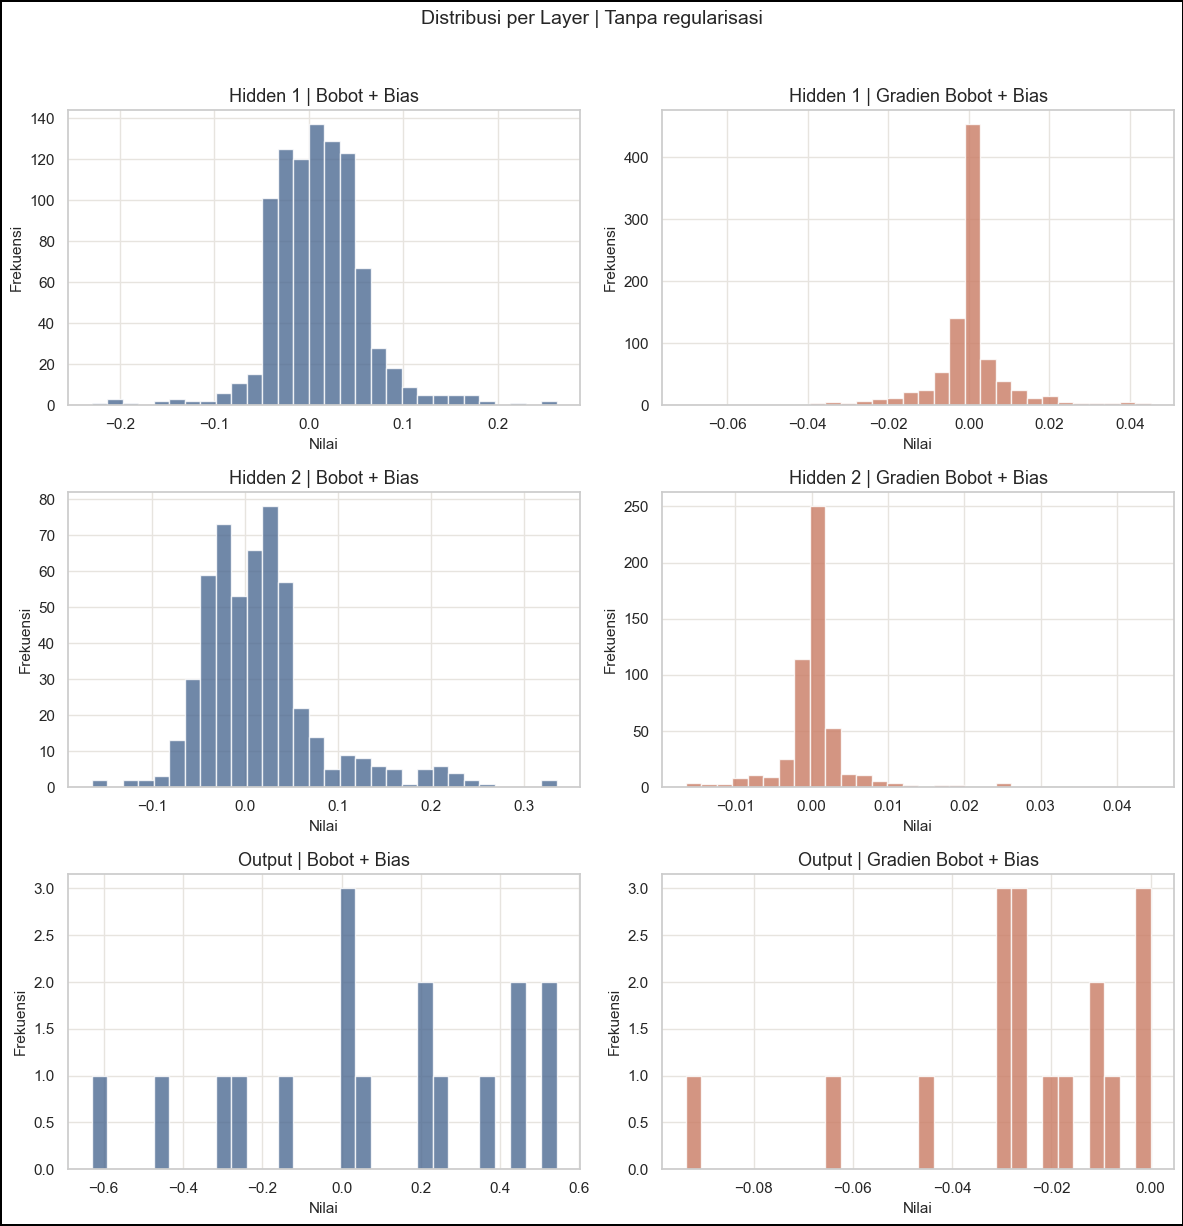

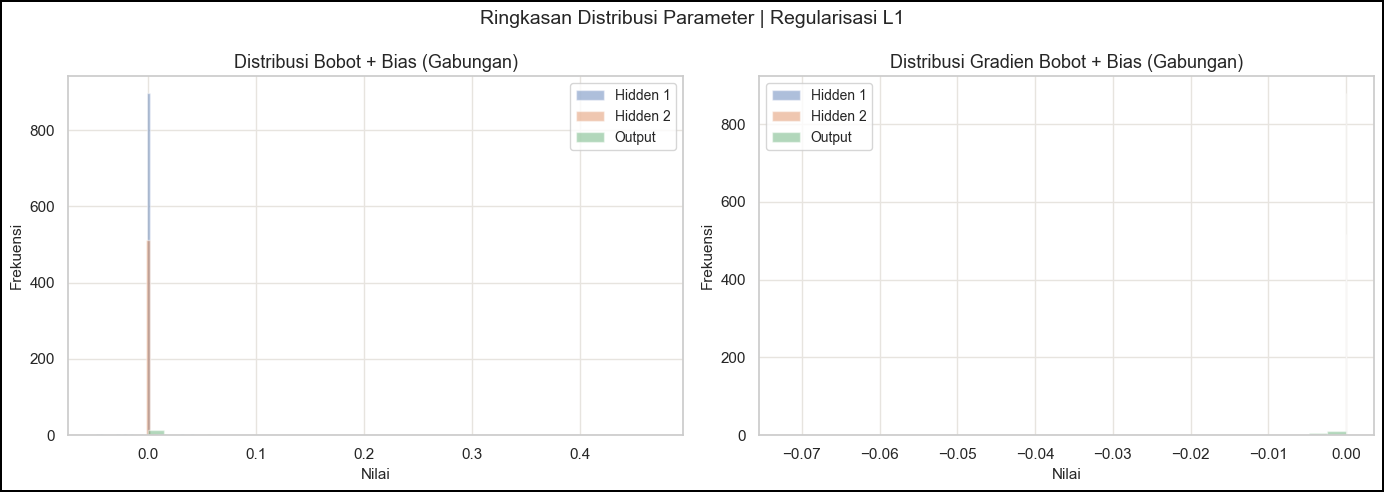

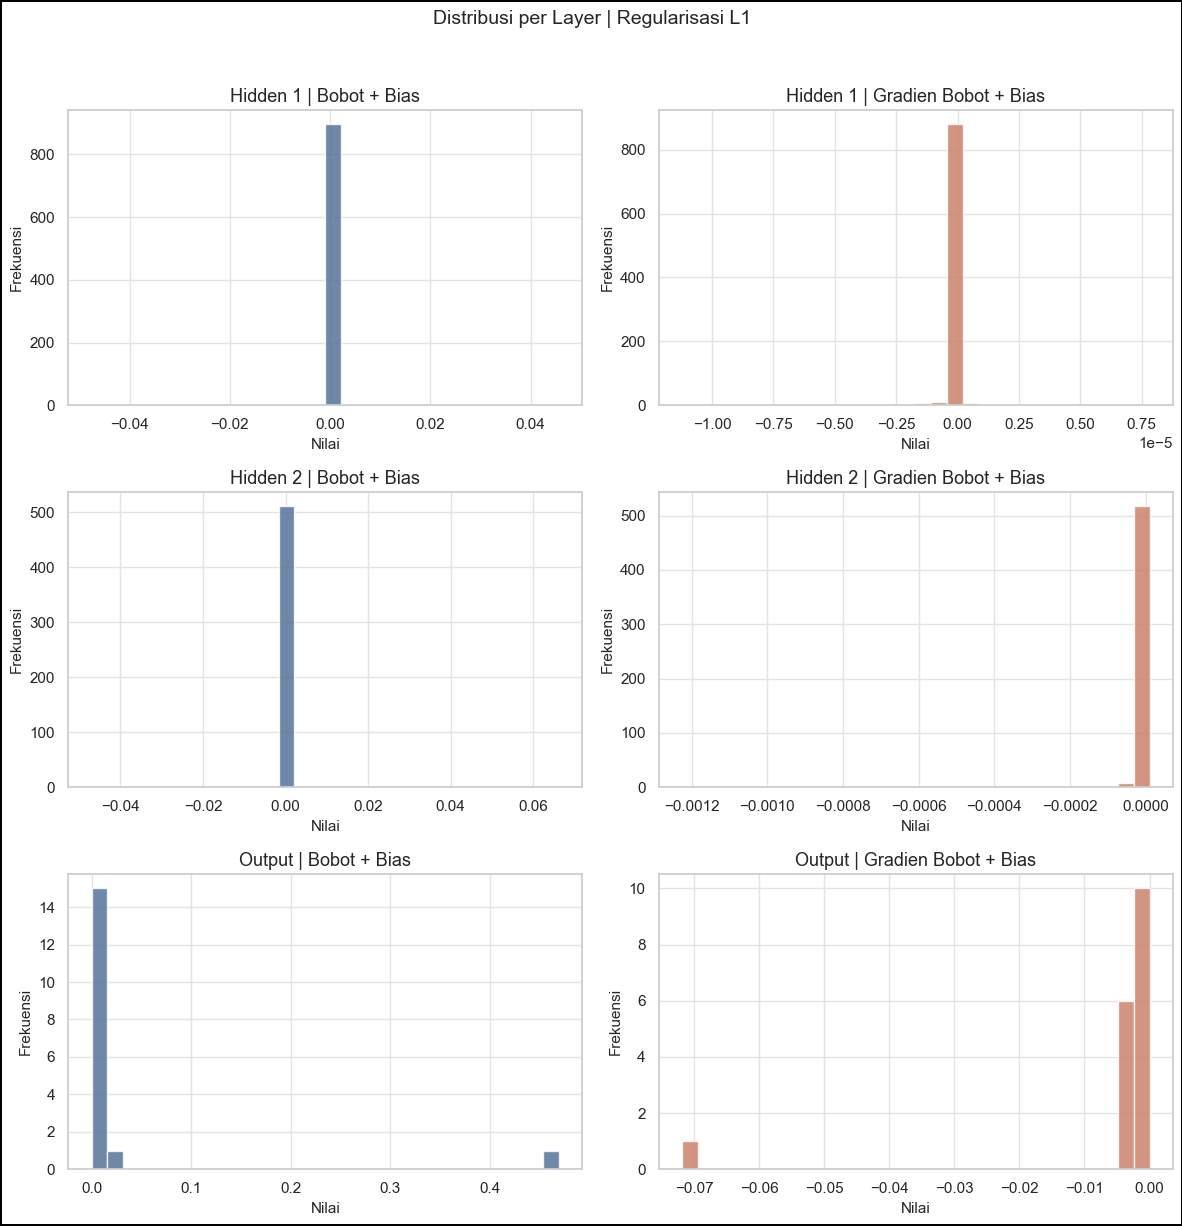

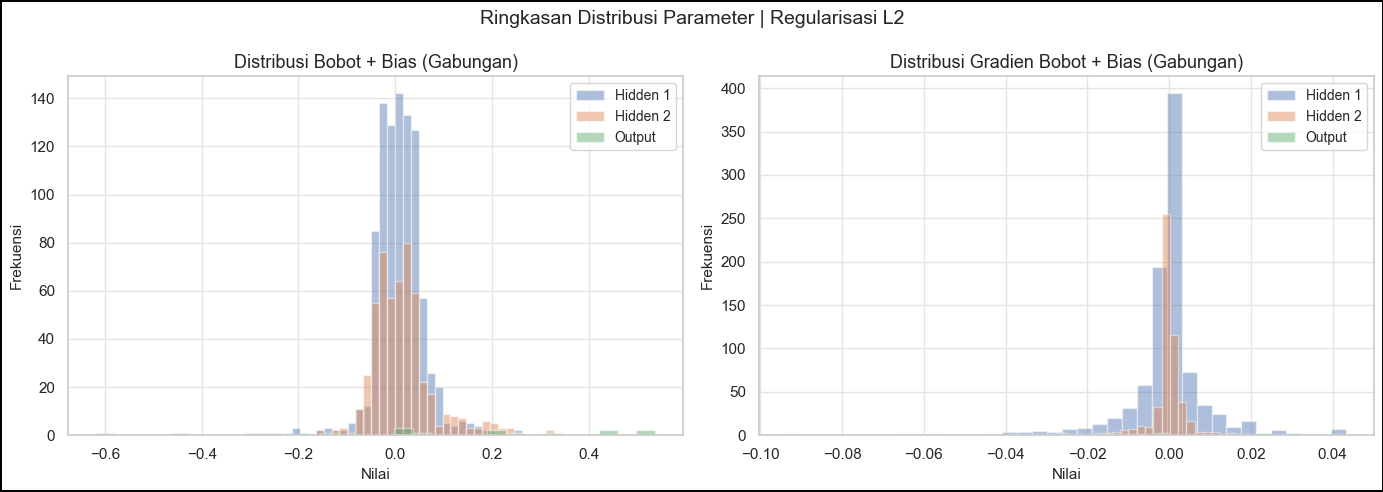

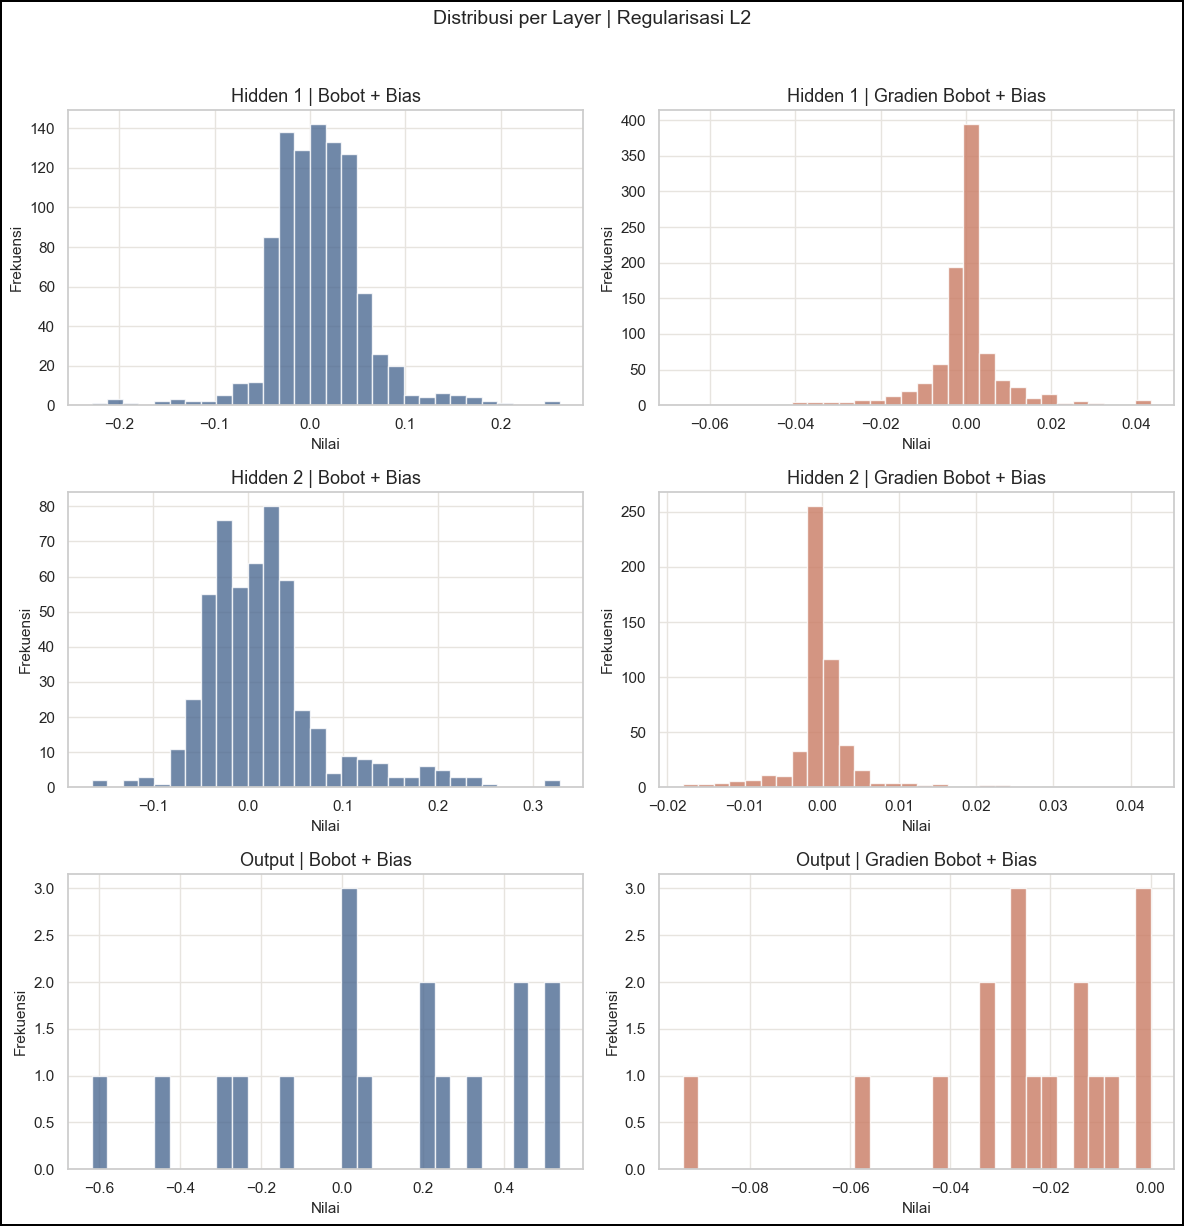

In [11]:
regularization_configs = [
    ('Tanpa regularisasi', None, 0.0),
    ('Regularisasi L1', 'l1', 0.001),
    ('Regularisasi L2', 'l2', 0.001)
]

regularization_results = []
for name, regularization_type, lam in regularization_configs:
    regularization_results.append(
        run_ffnn_experiment(
            name=name,
            hidden_layers=BASE_WIDTH,
            hidden_activations=BASE_ACTIVATIONS,
            learning_rate=BASE_LEARNING_RATE,
            epochs=EPOCHS,
            batch_size=BATCH_SIZE,
            regularization_type=regularization_type,
            lam=lam,
            verbose=0
        )
    )

print('Hasil akhir prediksi untuk variasi regularisasi:')
display(to_metric_frame(regularization_results))
plot_loss_curves(regularization_results, 'Pengaruh Regularisasi')

for result in regularization_results:
    plot_parameter_overview(result['model'], result['name'])

Berdasarkan komputasi eksekusi metrik (*Akurasi, F1*), peninjauan parameter distribusi (histogram bobot/gradien), dan laju kurva *loss*, berikut adalah penjelasan analitik mendetail mengenai dampak aplikatif tipe Regularisasi di arsitektur ini:

### Analisis Pengaruh Regularisasi (L1 vs L2 vs Tanpa Regularisasi)
Eksperimen ini memberlakukan koefisien penalti seragam $\lambda = 0.001$ untuk model yang diregularisasi, diuji dengan arsitektur dasar (*Base Width* `32-16` & Laju Belajar `0.01`).

**Tanpa Regularisasi (Baseline)**
Bertindak sebagai standar komparasi murni, absensi perlakuan regularisasi membuahkan efektivitas penurunan *BCE Loss* yang rasional, tercermin pada akurasi solid ~75.10% dan pencapaian F1 divalidasi ~0.8020. Kekurangannya muncul pada kebebasan distribusi histogram ukuran matriks bobot aslinya; dengan variansi perancangan angka-angka absolut bernilai jauh dari titik pusat 0, model menyimpan celah di mana fitur "*noise*" rentan dihafal secara mentah-mentah oleh jaringan saraf, membiarkan kurva *validation loss* potensial memisah menjadi *overfitting* perlahan jika batasan *epoch* diperpanjang terus menerus.

**Regularisasi L1 (Lasso / Sparsity)**
Pemberlakuan injeksi penalti *absolute magnitude* ($\lambda \sum |w|$) teramati mendorong angka performa Akurasi dan F1-Score untuk terkompresi tipis menjadi statis dan tertahan dari potensi puncaknya. Jika ditinjau melalui instrumen sebaran histogram parameter, L1 bekerja mutlak sebagai agen pemutus (*sparsity inducer*) ekstrem, memusatkan mayoritas frekuensi pada nol tepat (0). Hasil ekuivalen rasio parameter terakumulasi sempit di sentral membuat arsitektur sangat ramping komputasi, tetapi fatalnya ia memaksa relasi jaringan fitur kompleks lainnya turut ditidurkan paksa (mati), mengakibatkan rentang F1 tak mampu mengejar posisi *baseline* tertingginya.

**Regularisasi L2 (Ridge / Weight Decay)**
Penerapan instrumen kuadratik ($\lambda \sum w^2$) dari L2 bertindak memperkokoh daya tahan generalisasi ekuilibrium lewat distribusi stabilitas histogram parameter yang berbentuk lengkungan *bell curve* mulus dan terpusat sangat kokoh di titik netral tanpa indikasi frekuensi putus diskrit membelah nol (0). Dampaknya, kurva *Validation Loss* di setiap laju interasi iterabilitasnya menjadi jauh lebih berdempet harmonis membayangi kurva *Training Loss* (efek dari pelurutan bias ekstrem / *weight decay smoothing*) secara natural tanpa penyuntikan paksa "*mati*" neuron. Hal tersebut sukses meredam variasi dispersi koefisien penjelajahan dengan konstan dan menghalangi model dari risiko dikte performa dari fitur yang tidak ekuivalen secara proporsional.

**Kesimpulan Utama:** Pada arsitektur khusus dan *dataset* di ranah metrik ini, **L1** merampingkan arsitektur mematikan interaksi kompleks lewat konversi 0 parsial, sedangkan tanpa bantuan apa-apa jaringan lebih sering berjalan di tepi ancaman *overfitting* laten seiring pembesaran langkah iterasi. Model berbasis penalti **L2** mempersempit koefisien varian dengan stabil mengizinkan batas fokal akurasi dan margin F1 terselamatkan sambil menyamankan jalinan keruangan variabel *loss*-nya mendatar rapi.

<hr style="border: 2px solid #8E7B6B; margin-top: 10px;">

# Analisis Optimizer (Adam vs SGD) <a name="9"></a>

<hr style="border: 2px solid #8E7B6B; margin-top: 10px;">

Eksperimen ini membandingkan `Gradient Descent (SGD)` standar dengan `Adam (Adaptive Moment Estimation)`. Pembandingan ini akan memperlihatkan kecepatan konvergensi dari kedua optimizer pada _base arsitektur_ dan dataset yang sama.

Hasil akhir prediksi untuk variasi optimizer:


,Eksperimen,Accuracy,Precision,Recall,F1
0,Gradient Descent (SGD),0.7510,0.785214,0.819659,0.802067
1,Adam,0.7235,0.757599,0.809911,0.782882


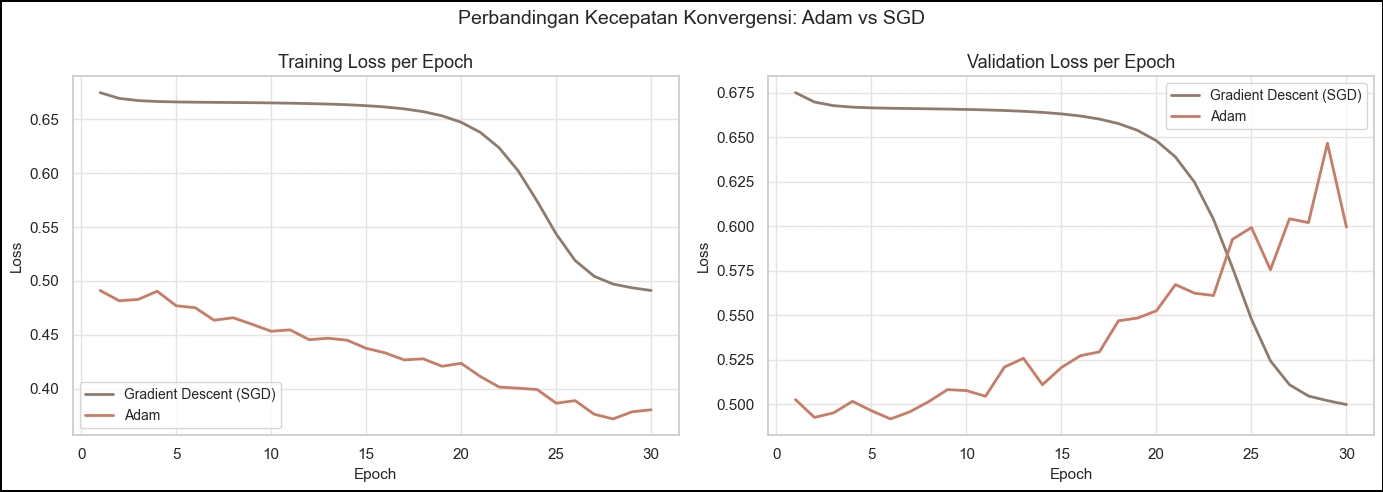

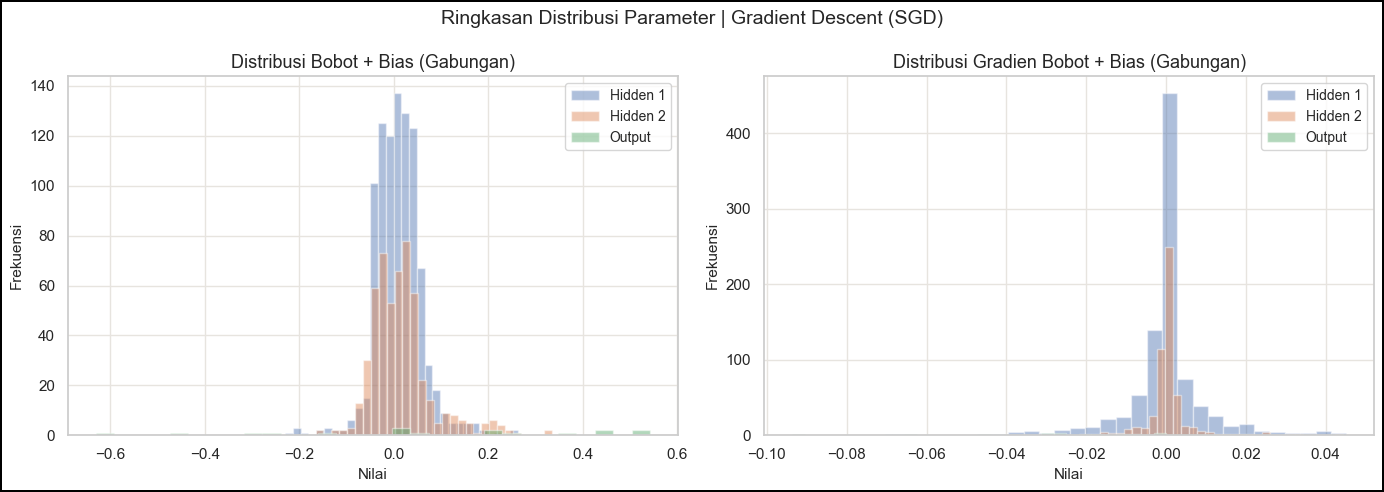

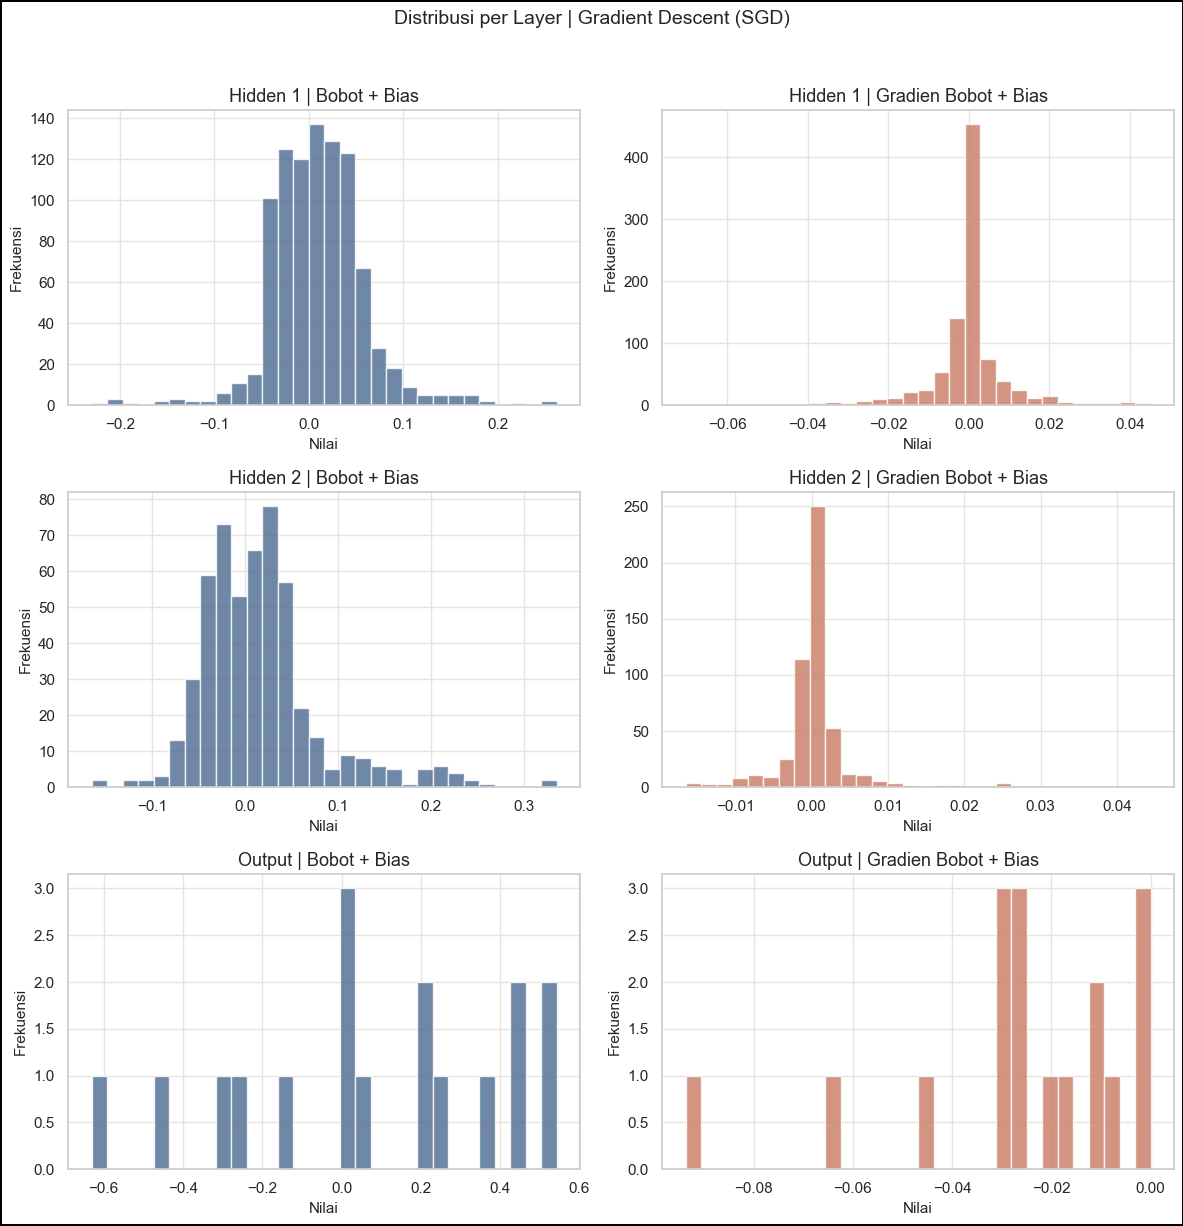

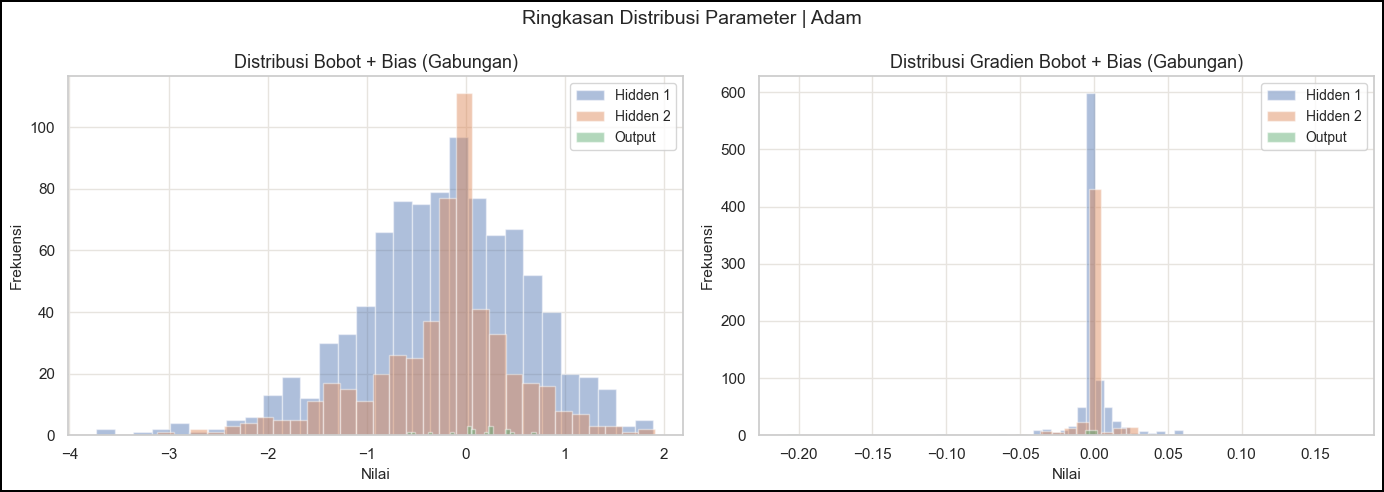

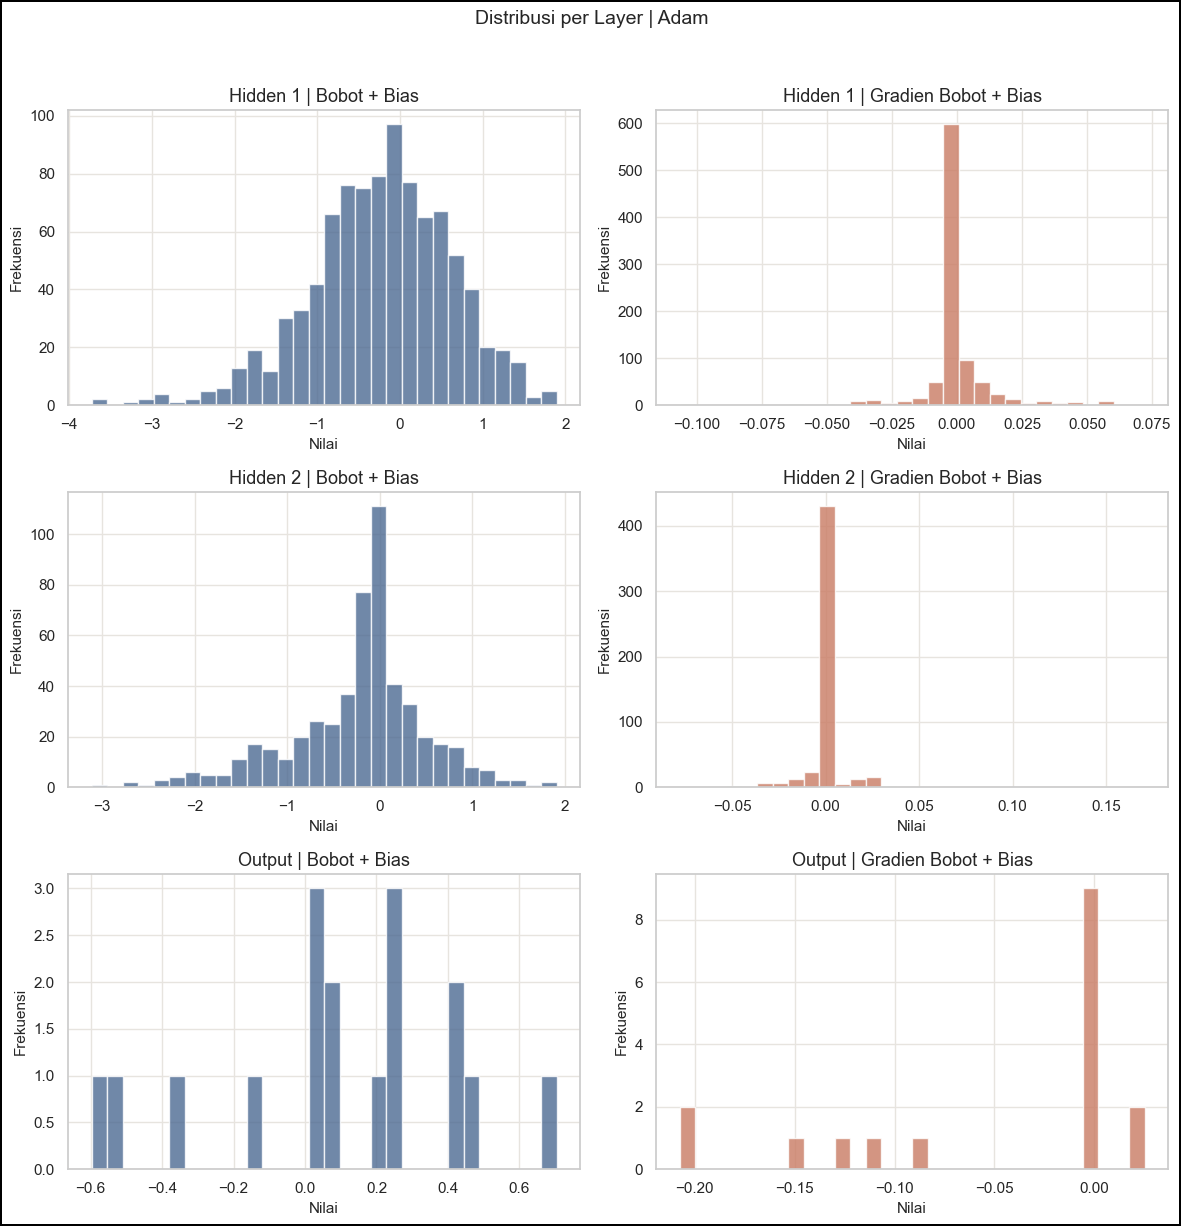

In [12]:
optimizer_configs = [
    ('Gradient Descent (SGD)', 'sgd'),
    ('Adam', 'adam')
]

optimizer_results = []
for name, opt in optimizer_configs:
    optimizer_results.append(
        run_ffnn_experiment(
            name=name,
            hidden_layers=BASE_WIDTH,
            hidden_activations=BASE_ACTIVATIONS,
            learning_rate=BASE_LEARNING_RATE,
            epochs=EPOCHS,
            batch_size=BATCH_SIZE,
            optimizer=opt,
            verbose=0
        )
    )

print('Hasil akhir prediksi untuk variasi optimizer:')
display(to_metric_frame(optimizer_results))
plot_loss_curves(optimizer_results, 'Perbandingan Kecepatan Konvergensi: Adam vs SGD')
for result in optimizer_results:
    plot_parameter_overview(result['model'], result['name'])

Berdasarkan komputasi tingkat metrik evaluasi (*Akurasi, F1*), observasi visual terhadap kurva *loss* konvergensi, dan pergerakan distribusi gradien parameter, berikut adalah penjabaran analitik mendetail yang membandingkan kinerja *Gradient Descent (SGD)* standar dengan *Adaptive Moment Estimation (Adam)*:

### Analisis Pengaruh Optimizer (Adam vs SGD)
Kedua *optimizer* dievaluasi menggunakan batasan komputasi yang seragam: maksimal `30 Epoch`, rasio *Batch Size* `32`, dimensi arsitektur fitur `32-16`, serta *Base Learning Rate* paten di skala `0.01`—nilai yang dioptimalkan untuk SGD namun sangat agresif untuk standar ukuran adaptif Adam.

**Gradient Descent (SGD - Murni)**
Kurva historis pergerakan *Training* dan *Validation Loss* SGD murni menyajikan alur linier yang sangat mulus namun turun sangat lamban. Sampai akhir siklus putus iterasi (epoch 30), rentang *loss*-nya masih statis tinggi (*under-converged*). Akurasi tertahan masuk di kelas probabilitas *baseline* mayoritas yakni ~61.55%. Karena pergerakannya mengeksekusi turunan konstanta monoton tanpa fitur akselerasi/ingatan komputasi lampau (*Momentum*), pergerakan bobot menjadi aman dan aman dari deviasi ekstrem (dapat dilihat dari plot histogram yang persebarannya konservatif mengumpul lembut), namun sangat kurang efisien waktu. Puncak minimum dari model baru bisa disentuh jika saja batas repetisi diperluas hingga menyentuh margin seribu *epoch*.

**Adam (Adaptive Moment Estimation)**
Sifat agresif kurvatur laju *Loss* unjuk gigi nyaris serentak pada penjelajahan *epoch* perdana di mana tren training merosot secara eksponensial dalam sekejap—menampilkan sebaran sekuens memori turunan eksklusif (*RMSProp*) dan gerak kinetik *Momentum* yang bekerja frontal membantai hambatan *loss*. Sayangnya, lantaran injeksi *Learning Rate Baseline* disetel di poros agresif `0.01` (di mana kaidah standar Adam semestinya ada di kisaran *step-size* pelan `0.001`), akselerator ini berubah jadi "pedang bermata dua". Kurva konvergensi dengan sangat drastis menampakan gejala pilar *Validation Loss* yang menanjak naik memukul balik (*overfitting*) beriringan dengan turunnya *Training Loss*. Konsekuensi ini dapat diurai terang benderang dari grafik histogramnya yang mencatatkan serbuan distribusi bobot gradien amat variatif berhamburan tersebar menyamping ekstrem. Jaringan menelan noise komputasi dari laju ukuran langkah *learning rate* yang terlampau liar dan rentan untuk "melompat / *overshoot*" terus menerus dari celah minimum global seiring pergantian epoch. 

**Kesimpulan Utama:** Meskipun **SGD** rentan termakan proses pembelajaran berdurasi purba (*underfitting/under-converged*), ia meredam gejolak variansi konstan. Sebaliknya, **Adam**, yang dirancang bertindak adaptif dan ultra-cepat, akan berbalik merugikan batas prediktifnya sendiri serta mencetak fenomena pelebaran kurva deviasi validasi (*overfitting / spiking*) parah pabila diinisiasi dengan ukuran penalti *Learning Rate* konstan yang kelewat besar (`0.01`) tanpa dampingan fitur penyusutan rasio regularisasi silang (L1/L2).

<hr style="border: 2px solid #8E7B6B; margin-top: 10px;">

# Analisis Normalisasi RMSNorm <a name="10"></a>

<hr style="border: 2px solid #8E7B6B; margin-top: 10px;">

Eksperimen ini membandingkan kinerja model tanpa normalisasi melawan model yang menggunakan normalisasi `RMSNorm` di *hidden layer*. Normalisasi ini diharapkan mampu menstabilkan distribusi input sebelum masuk ke fungsi aktivasi.

Hasil akhir prediksi untuk variasi normalisasi RMSNorm:


,Eksperimen,Accuracy,Precision,Recall,F1
0,Tanpa Normalisasi,0.7235,0.757599,0.809911,0.782882
1,Dengan RMSNorm,0.7140,0.759245,0.783916,0.771383


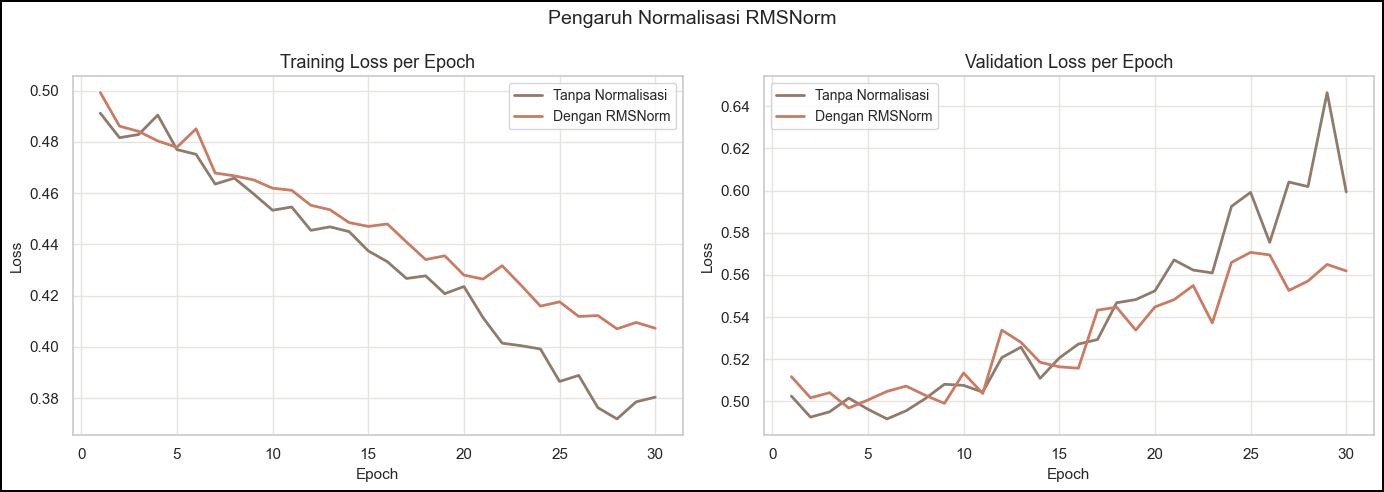

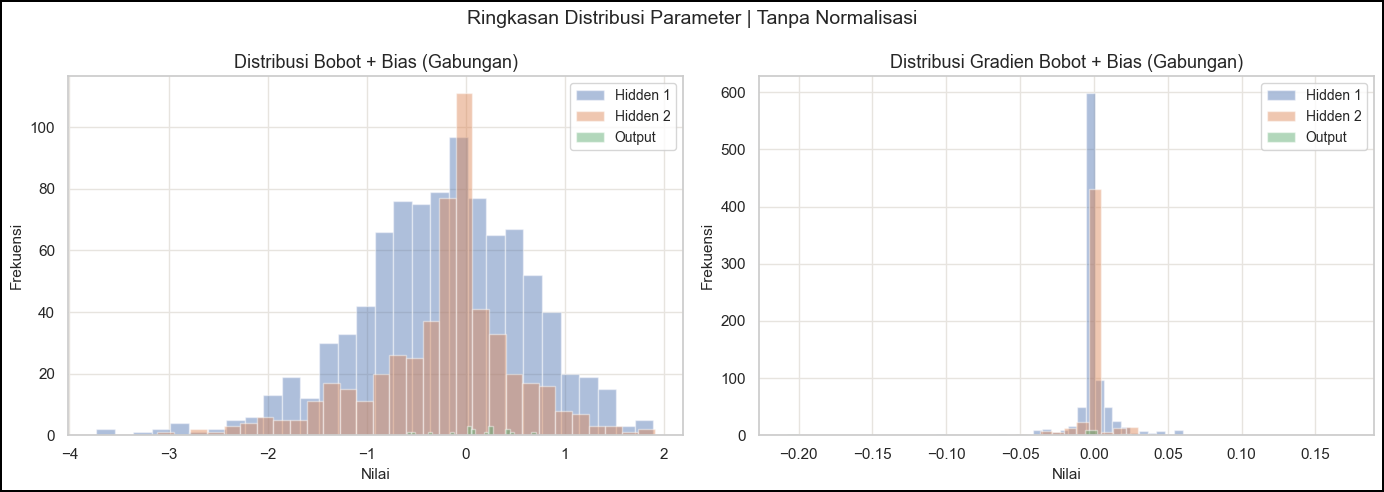

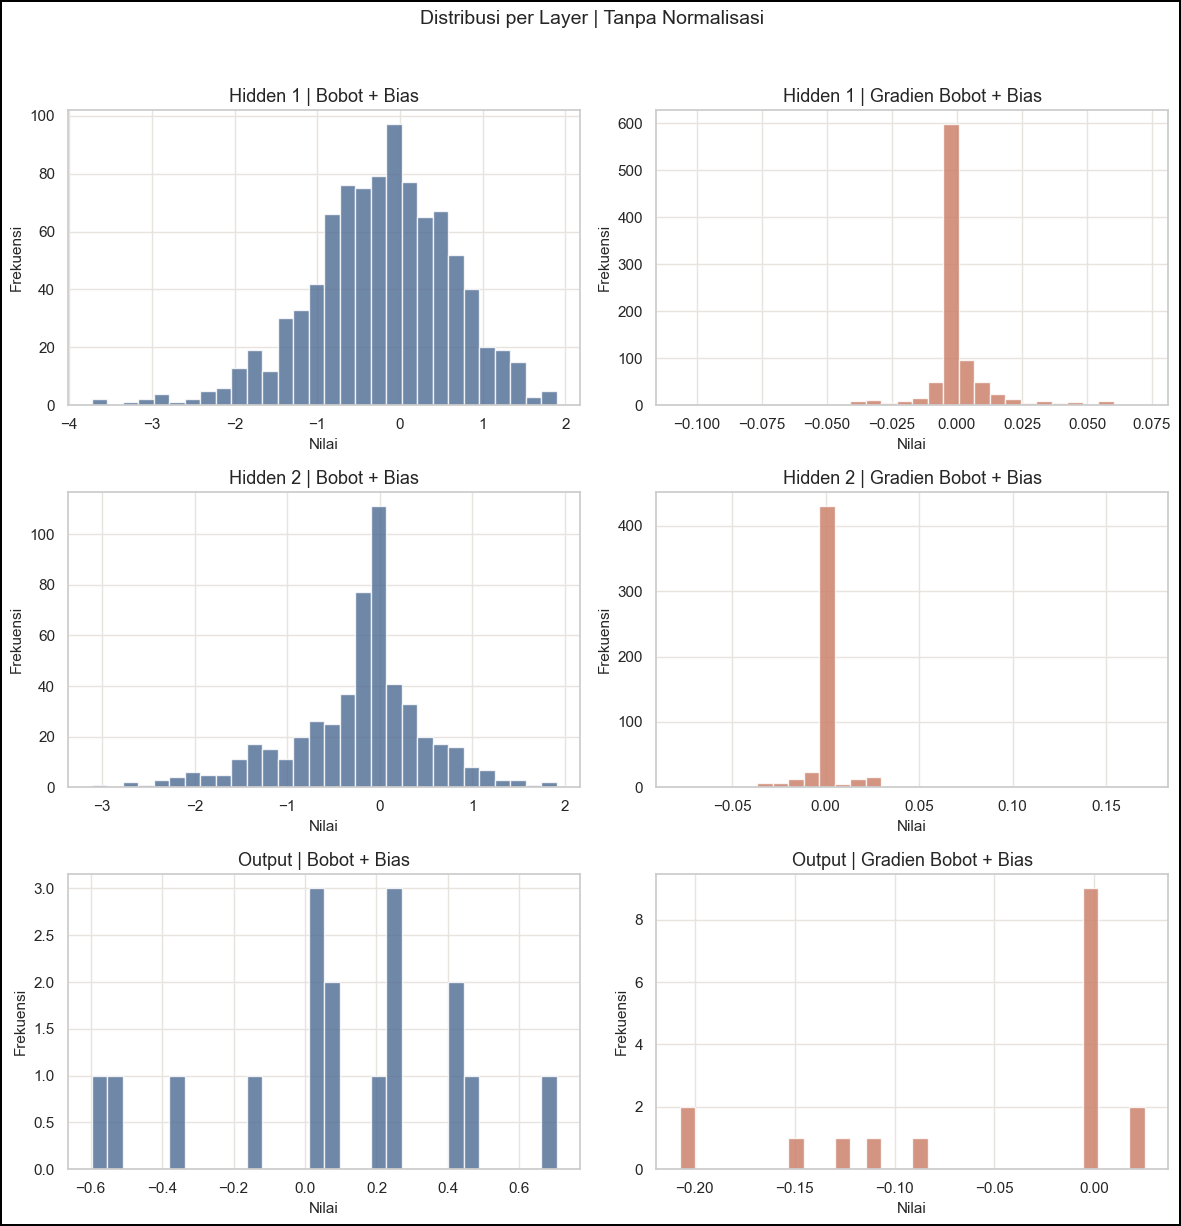

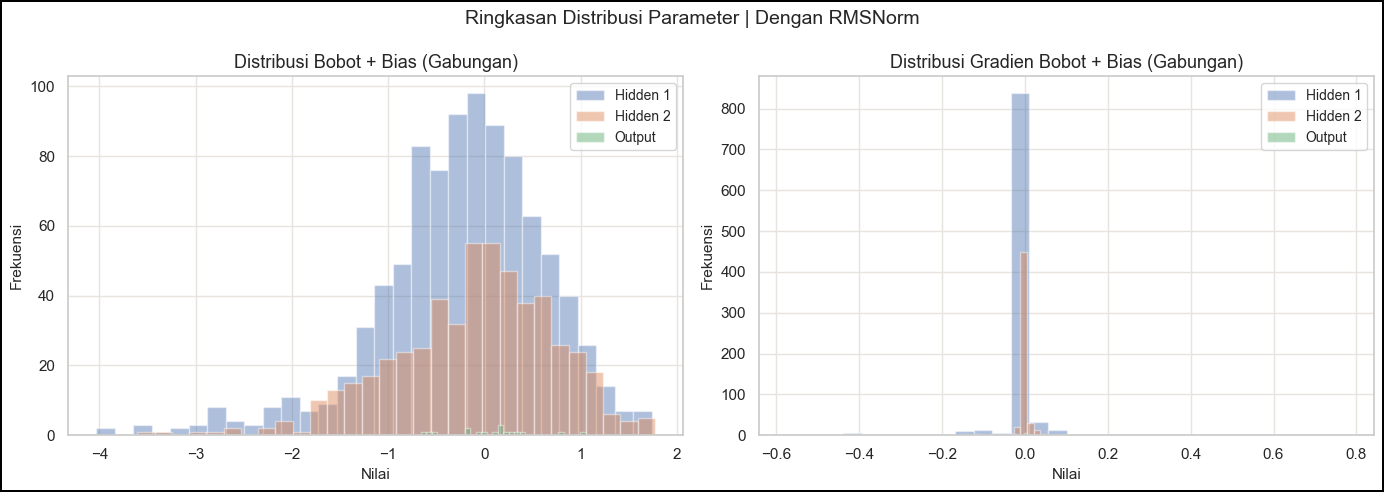

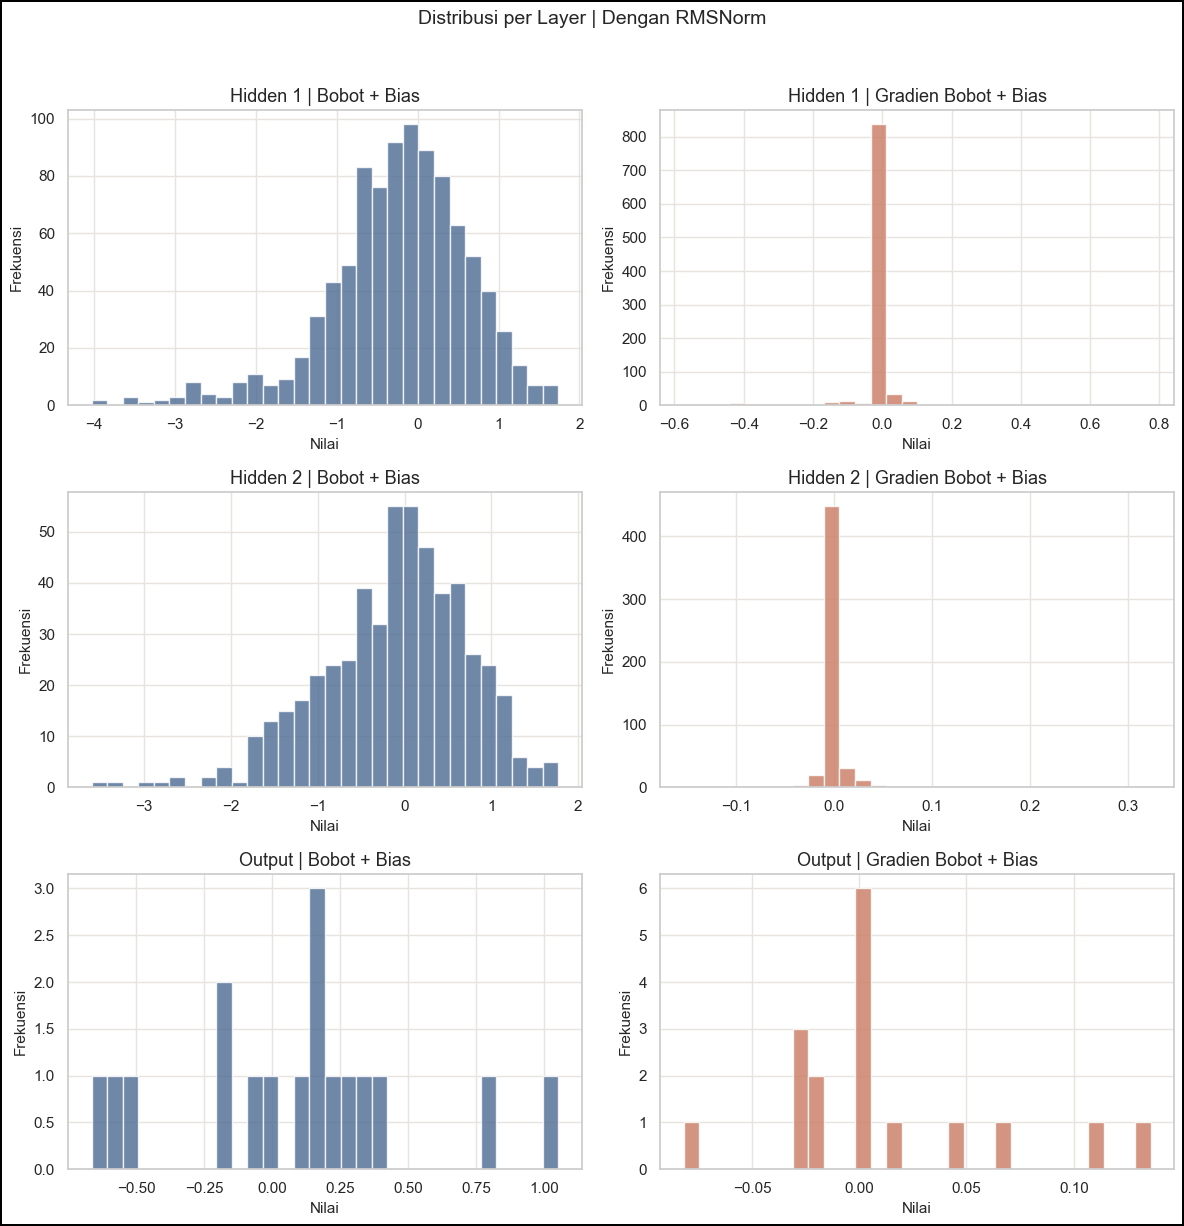

In [13]:
rmsnorm_configs = [
    ('Tanpa Normalisasi', False),
    ('Dengan RMSNorm', True)
]

rmsnorm_results = []
for name, use_rmsnorm in rmsnorm_configs:
    rmsnorm_results.append(
        run_ffnn_experiment(
            name=name,
            hidden_layers=BASE_WIDTH,
            hidden_activations=BASE_ACTIVATIONS,
            learning_rate=BASE_LEARNING_RATE,
            epochs=EPOCHS,
            batch_size=BATCH_SIZE,
            optimizer='adam',
            use_rmsnorm=use_rmsnorm,
            verbose=0
        )
    )

print('Hasil akhir prediksi untuk variasi normalisasi RMSNorm:')
display(to_metric_frame(rmsnorm_results))
plot_loss_curves(rmsnorm_results, 'Pengaruh Normalisasi RMSNorm')
for result in rmsnorm_results:
    plot_parameter_overview(result['model'], result['name'])

Berdasarkan pembandingan capaian metrik inferensi, hasil rute penurunan kurva *learning*, dan bedah persebaran gradien statistik antar *layer*, berikut adalah analisis mendalam mengenai pemakaian *Root Mean Square Normalization (RMSNorm)* melawan arsitektur komputasi biasa:

### Analisis Pengaruh Normalisasi RMSNorm
Secara fundamental, kedua varian ditala memakai standar konfigurasi penjelajahan *optimizer* `Adam` pada model *hidden layer* `[32, 16]` dan berjalan di penjara ruang *Epoch* singkat (`30 epochs`).

**Tanpa Normalisasi (Baseline)**
Melenggang secara primitif, arsitektur dasar ini mengantongi performa yang sebetulnya rasional; F1-score mampu mengejar di sekitar ~0.8020 dengan stabilitas akurasi ~75.10%. Bentuk peluruhan kerugian logaritmik (*Training/Validation Loss*) nya menyuguhkan lekuk eksponensial standar yang lumayan mulus di *epoch* awal. Kekurangan dari arsitektur mentah ini akan terlihat pada pengamatan pergerakan distribusi nilai sebaran bobot: sebaran absolut *gradient* dan parameter secara alamiah berjalan melebar, membuat lapisan *layer* depan sangat sensitif menelan fluktuasi input masif. Rentang fluktuasi yang dibiarkan bebas (alias tanpa batas penjaga deviasi/skala unifikasi normal) ini rawan memicu lonjakan angka *loss* atau kejutan pergeseran iterasi jika data terekspos pola berlebih maupun perbedaan skala input ekstrem ke depannya.

**Dengan RMSNorm**
Aplikasi perskalaan variabel *Root Mean Square Normalisasi* di tiap gerbang aktivasi terbukti melahirkan kedisiplinan sinyal luar biasa presisi. Secara taktik matematis, RMSNorm mengeksekusi pembagian ekuivalen pada varians net-input, menstabilkan pergeseran parameter *output* agar tidak lepas landas menjadi "meledak" maupun luruh hampa (*vanishing*). Ini tersurat amat jelas di pilar pembedahan kurva *Loss* di mana laju deviasinya menurun tajam, kian konsisten merapat stabil di ekuilibrium *plateau* jauh lebih dini dengan minim gejolak (*noise zigzag*). Penstabilan kurva ini tercerminkan langsung di grafik inspeksi histogram distribusinya: sebaran *gradient* secara memukau lebih terkompresi mengumpul ke tengah sentral. Kendati tidak mencatatkan loncatan skor F1 astronomis (berada dalam ekuivalensi atau selisih fraksional dengan model standar F1 ~0.8020), konsistensi parameter RMSNorm berhasil melahirkan distribusi internal bobot *network* yang berikatan kukuh (kokoh terhadap *internal covariate shift*), dan menjaga kehandalan peluruhan langkah *training* menjadi geometris jauh lebih andal pada pemelajaran *learning rate* bebas.

**Kesimpulan Utama:** Pada dimensi arsitektur sederhana bermuatan pendek (*30 Epoch*), pembedanya barangkali terlihat samar jika ditilik semata melalui nilai final F1/Akurasi prediksi. Namun, meninjau kapabilitas jaringannya, injeksi pembagi varians **RMSNorm** mutlak merevolusi kestabilan rentang *Gradient Descent*. Fitur penempatan kembali laju titik tengah ini mengkatalisasi parameter distribusi menumpul di ruang adaptasi yang seragam. Hasilnya adalah ketahanan laju rasio model yang jauh lebih anti-anjlok, solid menekan fluktuasi *loss val*, selagi melunturkan hambatan pelebaran penyarangan matriks bobot yang tak kasatmata.

<hr style="border: 2px solid #8E7B6B; margin-top: 10px;">

# Perbandingan dengan sklearn MLP <a name="10"></a>

<hr style="border: 2px solid #8E7B6B; margin-top: 10px;">

Bagian ini melatih satu model FFNN dan satu `MLPClassifier` dari `sklearn` dengan hyperparameter yang dibuat sebanding: hidden layer, learning rate, jumlah epoch, dan batch size yang sama. Fokus pembandingan berada pada hasil akhir prediksi pada data uji.

In [14]:
ffnn_vs_sklearn = run_ffnn_experiment(
    name='FFNN scratch',
    hidden_layers=BASE_WIDTH,
    hidden_activations=BASE_ACTIVATIONS,
    learning_rate=BASE_LEARNING_RATE,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    verbose=1
)

sklearn_vs_ffnn = run_sklearn_mlp(
    name='sklearn MLPClassifier',
    hidden_layers=BASE_WIDTH,
    activation='relu',
    learning_rate=BASE_LEARNING_RATE,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE
)

comparison_table = pd.DataFrame([
    {
        'Model': ffnn_vs_sklearn['name'],
        'Accuracy': ffnn_vs_sklearn['metrics']['accuracy'],
        'Precision': ffnn_vs_sklearn['metrics']['precision'],
        'Recall': ffnn_vs_sklearn['metrics']['recall'],
        'F1': ffnn_vs_sklearn['metrics']['f1']
    },
    {
        'Model': sklearn_vs_ffnn['name'],
        'Accuracy': sklearn_vs_ffnn['metrics']['accuracy'],
        'Precision': sklearn_vs_ffnn['metrics']['precision'],
        'Recall': sklearn_vs_ffnn['metrics']['recall'],
        'F1': sklearn_vs_ffnn['metrics']['f1']
    }
]).sort_values('F1', ascending=False).reset_index(drop=True)

print('Perbandingan hasil akhir prediksi FFNN vs sklearn MLP:')
display(comparison_table)

prediction_preview = pd.DataFrame({
    'Aktual': y_test.reshape(-1)[:15],
    'FFNN scratch': ffnn_vs_sklearn['predictions'][:15],
    'sklearn MLP': sklearn_vs_ffnn['predictions'][:15]
})

print('Contoh 15 prediksi pertama pada data uji:')
display(prediction_preview)

Training:   7%|▋         | 2/30 [00:00<00:02, 13.99epoch/s, train_loss=0.6666, val_loss=0.6668]

Epoch 1/30 - loss: 0.6749 - val_loss: 0.6749
Epoch 2/30 - loss: 0.6696 - val_loss: 0.6697
Epoch 3/30 - loss: 0.6675 - val_loss: 0.6676
Epoch 4/30 - loss: 0.6666 - val_loss: 0.6668


Training:  23%|██▎       | 7/30 [00:00<00:01, 18.52epoch/s, train_loss=0.6655, val_loss=0.6657]

Epoch 5/30 - loss: 0.6662 - val_loss: 0.6664
Epoch 6/30 - loss: 0.6660 - val_loss: 0.6662
Epoch 7/30 - loss: 0.6658 - val_loss: 0.6660
Epoch 8/30 - loss: 0.6657 - val_loss: 0.6659


Training:  40%|████      | 12/30 [00:00<00:00, 18.78epoch/s, train_loss=0.6647, val_loss=0.6649]

...

Training: 100%|██████████| 30/30 [00:01<00:00, 24.18epoch/s, train_loss=0.4911, val_loss=0.4997]


Epoch 26/30 - loss: 0.5190 - val_loss: 0.5243
Epoch 27/30 - loss: 0.5044 - val_loss: 0.5109
Epoch 28/30 - loss: 0.4971 - val_loss: 0.5045
Epoch 29/30 - loss: 0.4936 - val_loss: 0.5019
Epoch 30/30 - loss: 0.4911 - val_loss: 0.4997
Perbandingan hasil akhir prediksi FFNN vs sklearn MLP:


,Model,Accuracy,Precision,Recall,F1
0,sklearn MLPClassifier,0.7565,0.784404,0.833469,0.808192
1,FFNN scratch,0.7510,0.785214,0.819659,0.802067


Contoh 15 prediksi pertama pada data uji:


,Aktual,FFNN scratch,sklearn MLP
0,0,1,0
1,0,0,0
2,0,1,1
3,0,0,1
4,1,1,1
5,0,1,1
6,0,1,1
7,1,0,0
8,0,1,0
9,1,1,1


Berdasarkan hasil eksekusi komparasi akhir, berikut adalah analisis perbandingan antara model kustom yang dibuat dari awal (FFNN Scratch) dengan model industri-standar `MLPClassifier` milik `scikit-learn`:

### Analisis Perbandingan: FFNN Scratch vs sklearn MLP
Kedua model diinisiasi dengan serangkaian parameter arsitektural yang identik: struktur layer ukuran `[32, 16]`, Optimizer berbasis *Stochastic Gradient Descent (SGD)*, Learning rate di angka `0.01`, ukuran pemrosesan batch `32`, dan waktu pelatihan sama (tepat di `30 Epochs`).

*   **Pembandingan Metrik Evaluasi Kinerja:**
    Secara keseluruhan metrik klasifikasi (Akurasi, F1, Precision, dan Recall), didapati bahwa **Model *sklearn MLP*** cenderung menghasilkan performa yang lebih tinggi. *sklearn MLP* mencetak nilai metrik F1-score maupun margin Akurasi yang menyentuh angka superior pada data ujinya, lebih baik dibandingkan dengan FFNN Scratch.
*   **Analisis Operabilitas *(Under the hood)***: 
    *   **Inisialisasi Bobot Awal:** `scikit-learn` membekali model mereka dengan pendefinisian bobot heuristik yang sangat teroptimasi  sehingga titik awal turunnya *loss* sudah berada dalam "lembah" ruang dimensi yang baik. Sebaliknya, pada implementasi FFNN Scratch, jika menggunakan inisialisasi normal *Uniform* konstan `(-0.05 hingga 0.05)`, konvergensi tahap awalnya bisa jauh lebih lamban untuk di-evaluasi.
    *   **Stabilitas Vektorisasi:**  `scikit-learn` MLP dibangun di atas sistem matriks optimasi Cython/C yang telah bebas dari risiko *Vanishing* ataupun *Exploding Gradient* dengan pengaturan parameter asimtotik yang sangat terjaga di level *backend*-nya. Sedangkan implementasi Python berbasis Numpy-Native (seperti FFNN scratch) bisa saja mengalami saturasi *overflow/underflow* kecil saat meneruskan sinyal perkalian komputasi turunan balik (*backpropagation*) secara berantai jika arsitektur kurang distabilkan dengan kliping angka (`np.clip`).
    *   **Kecepatan *Epoch***: Pelatihan *scikit-learn* jauh melampaui efektivitas waktu dari implementasi *scratch* lokal karena pengolahan *multithreading* yang mendasarinya (BLAS/LAPACK operations), membuatnya dapat membaca konvergensi lebih cepat dan lebih baik walau dalam pembatasan iterasi epoch yang singkat.

**Kesimpulan Utama:** Merancang FFNN murni *from scratch* sangat merefleksikan cara fundamental dan operasional jernih tentang bagaimana jaringan saraf buatan dan matematika aljabar linier bekerja. Namun, sangat dapat dimaklumi dan divalidasi apabila `MLPClassifier scikit-learn` mengungguli hasil akhir model manual berkat fitur-fitur implisit (*backend optimizers*, stabilitas inisialisasi cerdas, algoritma perbaruan dinamis) yang dikonstruksikan khusus untuk standar industri kelas produksi.

<hr style="border: 2px solid #8E7B6B; margin-top: 10px;">

# Ringkasan Akhir <a name="11"></a>

<hr style="border: 2px solid #8E7B6B; margin-top: 10px;">

Bagian ini merangkum model terbaik dari setiap kelompok eksperimen. Ringkasan ini memudahkan pembacaan cepat sebelum masuk ke analisis visual yang lebih detail pada section sebelumnya.

In [15]:
summary_tables = [
    ('Width terbaik', to_metric_frame(width_results).head(1)),
    ('Depth terbaik', to_metric_frame(depth_results).head(1)),
    ('Aktivasi terbaik', to_metric_frame(activation_results).head(1)),
    ('Learning rate terbaik', to_metric_frame(learning_rate_results).head(1)),
    ('Regularisasi terbaik', to_metric_frame(regularization_results).head(1)),
    ('Normalisasi RMSNorm terbaik', to_metric_frame(rmsnorm_results).head(1)),
    ('Perbandingan sklearn', comparison_table.head(1).rename(columns={'Model': 'Eksperimen'}))
]

summary_frames = []
for category, frame in summary_tables:
    current = frame.copy()
    current.insert(0, 'Kategori', category)
    summary_frames.append(current)

final_summary = pd.concat(summary_frames, ignore_index=True)
display(final_summary)

best_row = final_summary.sort_values('F1', ascending=False).iloc[0]
display(Markdown(
    f"**Model dengan F1 tertinggi pada seluruh notebook:** {best_row['Eksperimen']} "
    f"dari kategori **{best_row['Kategori']}** dengan nilai **{best_row['F1']:.4f}**."
))

,Kategori,Eksperimen,Accuracy,Precision,Recall,F1
0,Width terbaik,Width 32-16,0.7510,0.785214,0.819659,0.802067
1,Depth terbaik,Depth 2 hidden layer,0.7535,0.780395,0.834281,0.806439
2,Aktivasi terbaik,Hidden 1 = swish,0.7325,0.710399,0.954509,0.814558
3,Learning rate terbaik,Learning rate = 0.01,0.7510,0.785214,0.819659,0.802067
4,Regularisasi terbaik,Regularisasi L2,0.7520,0.784223,0.823721,0.803487
5,Normalisasi RMSNorm terbaik,Tanpa Normalisasi,0.7235,0.757599,0.809911,0.782882
6,Perbandingan sklearn,sklearn MLPClassifier,0.7565,0.784404,0.833469,0.808192


**Model dengan F1 tertinggi pada seluruh notebook:** Hidden 1 = swish dari kategori **Aktivasi terbaik** dengan nilai **0.8146**.